In [ ]:
# ============================================================
# ECG fairness instability study — full pipeline
# Sudip Sharma et al. | Morgan State University, CEAMLS
#
# Trains 4 architectures x 10 seeds on PTB-XL, audits subgroup
# FNR/FPR/equalized-odds at a fixed and a per-seed calibrated
# threshold, runs Grad-CAM + noise-robustness checks on the
# baseline model, and validates zero-shot on the Georgia
# 12-lead ECG database.
#
# Checkpoints are cached to Google Drive, so re-running this
# notebook loads existing models instead of retraining them.
# ============================================================

# %%
# ============================================================
# BLOCK 1: Dependencies
# ============================================================

import subprocess, sys

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "wfdb", "pandas", "scikit-learn", "torch", "tqdm", "scipy"],
    check=True
)
print("Dependencies installed.")

Dependencies installed.


In [ ]:
# %%
# ============================================================
# BLOCK 2: Imports & Configuration
# ============================================================

import os, random, ast, time, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.signal import find_peaks, resample as sp_resample
from scipy.stats import norm as sp_norm, levene

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR, LinearLR, SequentialLR

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (roc_auc_score, f1_score, confusion_matrix,
                             brier_score_loss)
from sklearn.calibration import calibration_curve
from tqdm import tqdm
import wfdb

warnings.filterwarnings('ignore', category=DeprecationWarning)

# ----------------------------------------------------------
# Google Drive mount, ahead of any large download so a dropped
# Colab session never loses partial progress.
# ----------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/ecg_fairness_project'
os.makedirs(f'{PROJECT_DIR}/data', exist_ok=True)

# ----------------------------------------------------------
# Paths and class labels
# ----------------------------------------------------------
DATA_DIR = ('/content/fast_ptbxl/ptb-xl-a-large-publicly-available'
            '-electrocardiography-dataset-1.0.3')
CLASSES  = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

# ----------------------------------------------------------
# Training hyper-parameters
# ----------------------------------------------------------
BATCH_SIZE      = 32
MAX_EPOCHS      = 60
PATIENCE_ES     = 7
PATIENCE_LR     = 3
LR_INIT         = 1e-3
LR_TRANSFORMER  = 1e-4
LR_FACTOR       = 0.5
LR_MIN          = 1e-5
WEIGHT_DECAY    = 1e-4

# ----------------------------------------------------------
# Seeds for the multi-run stability analysis, fixed before any
# model was trained so seeds can't be picked after the fact.
# ----------------------------------------------------------
SEEDS = [42, 123, 2026, 7, 99, 256, 512, 777, 2024, 31415]

# Model colour palette (used across all figures)
MODEL_COLORS = {
    'Baseline 1D-CNN':        '#e63946',
    'Mitigated 1D-CNN':       '#457b9d',
    'Large 1D-CNN':           '#f4a261',
    'Hybrid CNN-Transformer': '#1d3557',
}

# Global results store
results = {'single_run': {}, 'multi_run': {}}
training_times = {}


def set_global_seed(seed: int) -> None:
    """Set all random sources for reproducible training."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False


set_global_seed(SEEDS[0])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}  |  Max epochs: {MAX_EPOCHS}  |  Seeds: {len(SEEDS)}")

Mounted at /content/drive
Device: cuda  |  Max epochs: 60  |  Seeds: 10


In [ ]:
# %%
# ============================================================
# BLOCK 3: Data Acquisition
#
# The zip is downloaded onto Google Drive rather than local Colab
# storage, so a dropped session resumes an in-progress download
# instead of restarting it. Extraction happens on local disk for
# fast per-file read throughput during training.
# ============================================================

ZIP_NAME       = 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip'
DRIVE_ZIP_PATH = f'{PROJECT_DIR}/data/{ZIP_NAME}'
ZIP_URL        = f'https://physionet.org/static/published-projects/ptb-xl/{ZIP_NAME}'

if os.path.exists(DATA_DIR):
    print(f"Dataset already extracted at: {DATA_DIR}")
else:
    print("Downloading PTB-XL to Google Drive...")
    subprocess.run(
        ["wget", "-c", "--tries=0", "--timeout=30",
         "--progress=bar:force:noscroll",
         "-O", DRIVE_ZIP_PATH, ZIP_URL],
        check=True
    )
    print("Extracting to local disk...")
    subprocess.run(
        ["unzip", "-q", "-o", DRIVE_ZIP_PATH, "-d", "/content/fast_ptbxl/"],
        check=True
    )
    assert os.path.exists(DATA_DIR), f"Extraction failed. Expected: {DATA_DIR}"
    print(f"Dataset ready: {DATA_DIR}")

Extracting to local disk...
Dataset ready: /content/fast_ptbxl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3


In [ ]:
# %%
# ============================================================
# BLOCK 4: Preprocessing & Official Train / Val / Test Split
#
# SCP codes are mapped to five diagnostic superclasses following
# Strodthoff et al. (2021). Official stratified 10-fold split:
#   Folds 1-8  -> Train  (n ~ 17,441)
#   Fold  9    -> Val    (n ~  2,186)
#   Fold  10   -> Test   (n ~  2,210)   held-out, never seen during training
# ============================================================

df     = pd.read_csv(f'{DATA_DIR}/ptbxl_database.csv', index_col='ecg_id')
agg_df = pd.read_csv(f'{DATA_DIR}/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1.0]
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)


def aggregate_diagnostic(y_dic: dict) -> list:
    """Map SCP codes to PTB-XL diagnostic superclasses."""
    out = []
    for code in y_dic:
        if code in agg_df.index:
            cls = agg_df.loc[code, 'diagnostic_class']
            if pd.notna(cls):
                out.append(cls)
    return list(set(out))


df['super_classes'] = df['scp_codes'].apply(aggregate_diagnostic)

mlb            = MultiLabelBinarizer(classes=CLASSES)
encoded_labels = mlb.fit_transform(df['super_classes'])
for i, c in enumerate(CLASSES):
    df[f'label_{c}'] = encoded_labels[:, i]

train_df = df[df.strat_fold <= 8]
val_df   = df[df.strat_fold == 9]
test_df  = df[df.strat_fold == 10]

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
print("\nTraining set class prevalence:")
for c in CLASSES:
    print(f"  {c}: {int(train_df[f'label_{c}'].sum()):,}")

Train: 17,418  |  Val: 2,183  |  Test: 2,198

Training set class prevalence:
  NORM: 7,596
  MI: 4,379
  STTC: 4,186
  CD: 3,907
  HYP: 2,119


In [ ]:
# %%
# ============================================================
# BLOCK 5: Dataset, DataLoaders & Class-Frequency Weights
# ============================================================

class PTBXLDataset(Dataset):
    """
    Streaming loader for PTB-XL 100 Hz recordings.
    Per-lead z-score normalisation applied at read time.
    Returns (signal [12x1000], label [5], metadata dict).
    """
    def __init__(self, df: pd.DataFrame, data_dir: str, class_names: list):
        self.df       = df
        self.data_dir = data_dir
        self.labels   = df[[f'label_{c}' for c in class_names]].values.astype(np.float32)
        self.sex      = df['sex'].fillna(-1).values.astype(np.float32)
        self.age      = df['age'].fillna(df['age'].median()).values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path      = f"{self.data_dir}/{self.df.iloc[idx]['filename_lr']}"
        signal, _ = wfdb.rdsamp(path)
        signal    = signal.T
        mu        = signal.mean(axis=1, keepdims=True)
        sigma     = signal.std(axis=1, keepdims=True)
        signal    = (signal - mu) / (sigma + 1e-8)
        return (
            torch.tensor(signal, dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32),
            {'sex': self.sex[idx], 'age': self.age[idx], 'ecg_id': self.df.index[idx]},
        )


train_dataset = PTBXLDataset(train_df, DATA_DIR, CLASSES)
val_dataset   = PTBXLDataset(val_df,   DATA_DIR, CLASSES)
test_dataset  = PTBXLDataset(test_df,  DATA_DIR, CLASSES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

_train_labels = train_df[[f'label_{c}' for c in CLASSES]].values.astype(float)
_N            = float(len(_train_labels))
_pos          = _train_labels.sum(axis=0)
pos_weights   = torch.tensor((_N - _pos) / _pos, dtype=torch.float32)

print("Positive weights (Mitigated CNN):")
for c, w in zip(CLASSES, pos_weights.tolist()):
    print(f"  {c}: {w:.2f}")

for x, y, _ in train_loader:
    print(f"\nBatch shape — Signal: {x.shape}  Labels: {y.shape}")
    break

Positive weights (Mitigated CNN):
  NORM: 1.29
  MI: 2.98
  STTC: 3.16
  CD: 3.46
  HYP: 7.22

Batch shape — Signal: torch.Size([32, 12, 1000])  Labels: torch.Size([32, 5])


In [ ]:
# %%
# ============================================================
# BLOCK 6: Model Architectures
#
#   A. ECG_1D_CNN       (~47K)   Baseline and Mitigated CNN
#   B. ECG_Large_CNN    (~479K)  Parameter-matched capacity ablation
#   C. Hybrid_ECG_Transformer  (~313K)  CNN encoder + 2-layer Transformer
# ============================================================

class ECG_1D_CNN(nn.Module):
    """
    Three-block 1D-CNN (~47K parameters).
    features[8] is the last Conv1d and the Grad-CAM target layer.
    """
    def __init__(self, num_classes: int = 5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(12, 32, 7, padding=3),  nn.BatchNorm1d(32),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2),  nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x).squeeze(-1))


class ECG_Large_CNN(nn.Module):
    """
    Five-block 1D-CNN (~479K parameters).
    Parameter-matched to the Hybrid Transformer; disentangles the
    effect of self-attention from raw model capacity.
    """
    def __init__(self, num_classes: int = 5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(12,  64,  7, padding=3), nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64,  128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 256, 5, padding=2), nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(256, 224, 3, padding=1), nn.BatchNorm1d(224), nn.ReLU(),
            nn.Conv1d(224, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x).squeeze(-1))


class Hybrid_ECG_Transformer(nn.Module):
    """
    Strided CNN compresses (12, 1000) -> (128, 125); a 2-layer
    TransformerEncoder with 4-head attention then models inter-beat
    temporal context. (~313K parameters)
    """
    def __init__(self, num_classes: int = 5):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(12, 64, 7, stride=2, padding=3), nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 5, stride=2, padding=2),nn.BatchNorm1d(128), nn.ReLU(),
        )
        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=128, nhead=4, dim_feedforward=256, dropout=0.3, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.classifier  = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.cnn(x).permute(0, 2, 1)
        x = self.transformer(x).mean(dim=1)
        return self.classifier(x)


print("Architecture summary:")
for name, arch in [("Baseline / Mitigated 1D-CNN",    ECG_1D_CNN()),
                   ("Large 1D-CNN (capacity ablation)", ECG_Large_CNN()),
                   ("Hybrid CNN-Transformer",            Hybrid_ECG_Transformer())]:
    n = sum(p.numel() for p in arch.parameters() if p.requires_grad)
    print(f"  {name:<42}: {n:>7,} params")

Architecture summary:
  Baseline / Mitigated 1D-CNN               :  46,757 params
  Large 1D-CNN (capacity ablation)          : 479,205 params
  Hybrid CNN-Transformer                    : 312,517 params


In [ ]:
# %%
# ============================================================
# BLOCK 7: Early Stopping & Training
# ============================================================

class EarlyStopping:
    """Stop training and restore best weights when val loss plateaus."""
    def __init__(self, patience: int = PATIENCE_ES, min_delta: float = 1e-4):
        self.patience     = patience
        self.min_delta    = min_delta
        self.best_loss    = float('inf')
        self.counter      = 0
        self.best_weights = None
        self.triggered    = False

    def step(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss    = val_loss
            self.counter      = 0
            self.best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                if self.best_weights:
                    model.load_state_dict(self.best_weights)
                self.triggered = True
        return self.triggered


def _training_loop(model, train_loader, val_loader, criterion,
                   max_epochs, lr, label):
    """Shared loop returning (model, history)."""
    model     = model.to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=LR_FACTOR,
                                  patience=PATIENCE_LR, min_lr=LR_MIN)
    stopper   = EarlyStopping()
    history   = {'train_loss': [], 'val_loss': [], 'n_epochs': 0}

    for epoch in range(1, max_epochs + 1):
        model.train()
        t_loss = 0.0
        for x, y, _ in tqdm(train_loader, desc=f"[{label}] Epoch {epoch:03d} Train",
                             leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for x, y, _ in tqdm(val_loader, desc=f"[{label}] Epoch {epoch:03d} Val  ",
                                 leave=False):
                x, y = x.to(DEVICE), y.to(DEVICE)
                v_loss += criterion(model(x), y).item()

        avg_t = t_loss / len(train_loader)
        avg_v = v_loss / len(val_loader)
        scheduler.step(avg_v)
        history['train_loss'].append(avg_t)
        history['val_loss'].append(avg_v)
        history['n_epochs'] = epoch

        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:03d}/{max_epochs}  train {avg_t:.4f}  val {avg_v:.4f}  lr {lr_now:.2e}")

        if stopper.step(avg_v, model):
            print(f"Early stopping at epoch {epoch} (best val {stopper.best_loss:.4f}).")
            break

    return model, history


def train_model(model, train_loader, val_loader,
                max_epochs=MAX_EPOCHS, lr=LR_INIT):
    """Standard BCEWithLogitsLoss training."""
    return _training_loop(model, train_loader, val_loader,
                          nn.BCEWithLogitsLoss(), max_epochs, lr,
                          label=type(model).__name__)


def train_mitigated_model(model, train_loader, val_loader, pos_weights,
                          max_epochs=MAX_EPOCHS, lr=LR_INIT):
    """Class-frequency-weighted BCEWithLogitsLoss."""
    return _training_loop(model, train_loader, val_loader,
                          nn.BCEWithLogitsLoss(pos_weight=pos_weights.to(DEVICE)),
                          max_epochs, lr, label="Mitigated")


def train_transformer_model(model, train_loader, val_loader,
                             max_epochs=MAX_EPOCHS, lr=3e-4,
                             warmup_epochs=5):
    """Warmup + cosine decay schedule for Transformer training."""
    model     = model.to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=lr,
                            weight_decay=WEIGHT_DECAY)

    warmup_scheduler = LinearLR(optimizer, start_factor=0.05,
                                 end_factor=1.0, total_iters=warmup_epochs)
    cosine_scheduler = CosineAnnealingLR(optimizer,
                                          T_max=max_epochs - warmup_epochs,
                                          eta_min=LR_MIN)
    scheduler = SequentialLR(optimizer,
                              schedulers=[warmup_scheduler, cosine_scheduler],
                              milestones=[warmup_epochs])
    stopper   = EarlyStopping(patience=PATIENCE_ES)
    history   = {'train_loss': [], 'val_loss': [], 'n_epochs': 0}
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(1, max_epochs + 1):
        model.train()
        t_loss = 0.0
        for x, y, _ in tqdm(train_loader,
                             desc=f"[Transformer] Epoch {epoch:03d} Train",
                             leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            t_loss += loss.item()

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for x, y, _ in tqdm(val_loader,
                                 desc=f"[Transformer] Epoch {epoch:03d} Val  ",
                                 leave=False):
                x, y = x.to(DEVICE), y.to(DEVICE)
                v_loss += criterion(model(x), y).item()

        avg_t = t_loss / len(train_loader)
        avg_v = v_loss / len(val_loader)
        scheduler.step()
        history['train_loss'].append(avg_t)
        history['val_loss'].append(avg_v)
        history['n_epochs'] = epoch

        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:03d}/{max_epochs}  train {avg_t:.4f}  "
              f"val {avg_v:.4f}  lr {lr_now:.2e}")

        if stopper.step(avg_v, model):
            print(f"Early stopping at epoch {epoch} "
                  f"(best val {stopper.best_loss:.4f}).")
            break

    return model, history

In [ ]:
# %%
# ============================================================
# BLOCK 8: Subgroup Definitions & Inference
# ============================================================

SUBGROUPS = {
    'Young Male (<60)':   lambda s, a: (s == 0) & (a <  60),
    'Older Male (60+)':   lambda s, a: (s == 0) & (a >= 60),
    'Young Female (<60)': lambda s, a: (s == 1) & (a <  60),
    'Older Female (60+)': lambda s, a: (s == 1) & (a >= 60),
}


def get_predictions(model: nn.Module, loader: DataLoader) -> dict:
    """Run inference and return probs, preds (tau=0.5), targets, and metadata."""
    model.eval()
    probs_all, targets_all, sex_all, age_all = [], [], [], []

    with torch.no_grad():
        for x, y, meta in loader:
            p = torch.sigmoid(model(x.to(DEVICE))).cpu().numpy()
            probs_all.extend(p)
            targets_all.extend(y.numpy())
            sex_all.extend(meta['sex'].numpy())
            age_all.extend(meta['age'].numpy())

    probs = np.array(probs_all)
    return {
        'probs':   probs,
        'preds':   (probs > 0.5).astype(int),
        'targets': np.array(targets_all),
        'sex':     np.array(sex_all),
        'age':     np.array(age_all),
    }


def apply_thresholds(pred_dict: dict, thresholds: np.ndarray) -> dict:
    """
    Return a copy of pred_dict with class predictions recomputed at
    the given per-class thresholds instead of the fixed tau=0.5
    cutoff baked into get_predictions.
    """
    out = dict(pred_dict)
    out['preds'] = (pred_dict['probs'] > thresholds[np.newaxis, :]).astype(int)
    return out


def select_thresholds(model: nn.Module, loader: DataLoader,
                       grid: np.ndarray = np.linspace(0.05, 0.95, 19)) -> np.ndarray:
    """
    Per-class threshold maximising F1 on the validation set (never
    the test fold). Used for the threshold-recalibration check:
    does cross-seed FNR instability survive a per-seed calibrated
    threshold, or is it a fixed-cutoff artifact? (Section III-G)
    """
    pd_ = get_predictions(model, loader)
    thresholds = np.full(len(CLASSES), 0.5)
    for i in range(len(CLASSES)):
        probs, targets = pd_['probs'][:, i], pd_['targets'][:, i]
        if targets.sum() == 0:
            continue
        f1s = [f1_score(targets, (probs > t).astype(int), zero_division=0) for t in grid]
        thresholds[i] = grid[int(np.argmax(f1s))]
    return thresholds

In [ ]:
# %%
# ============================================================
# BLOCK 9: Evaluation & Fairness Audit Functions
# ============================================================

def compute_overall_metrics(pred_dict: dict) -> dict:
    """Macro-AUROC and macro-F1."""
    try:
        auroc = roc_auc_score(pred_dict['targets'], pred_dict['probs'], average='macro')
    except ValueError:
        auroc = 0.5
    f1 = f1_score(pred_dict['targets'], pred_dict['preds'],
                  average='macro', zero_division=0)
    return {'auroc': auroc, 'f1': f1}


def bootstrap_metric_ci(pred_dict: dict, metric: str = 'auroc',
                         n_boot: int = 1000, seed: int = 0) -> tuple:
    """Percentile bootstrap 95% CI for macro-AUROC or macro-F1."""
    rng      = np.random.default_rng(seed)
    n        = len(pred_dict['targets'])
    boot_vals = []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        t   = pred_dict['targets'][idx]
        p   = pred_dict['probs'][idx]
        pr  = pred_dict['preds'][idx]
        try:
            if metric == 'auroc':
                boot_vals.append(roc_auc_score(t, p, average='macro'))
            else:
                boot_vals.append(f1_score(t, pr, average='macro', zero_division=0))
        except ValueError:
            continue
    if not boot_vals:
        return (np.nan, np.nan)
    return (np.percentile(boot_vals, 2.5), np.percentile(boot_vals, 97.5))


def bootstrap_fnr_ci(targets: np.ndarray, preds: np.ndarray,
                     n_boot: int = 1000, seed: int = 0) -> tuple:
    """Percentile bootstrap 95% CI for FNR = FN / (FN + TP)."""
    if targets.sum() < 5:
        return (np.nan, np.nan)
    rng      = np.random.default_rng(seed)
    n        = len(targets)
    fnr_boot = []
    for _ in range(n_boot):
        idx  = rng.choice(n, size=n, replace=True)
        t, p = targets[idx], preds[idx]
        if t.sum() == 0:
            continue
        tn, fp, fn, tp = confusion_matrix(t, p, labels=[0, 1]).ravel()
        fnr_boot.append(fn / max(fn + tp, 1))
    if not fnr_boot:
        return (np.nan, np.nan)
    return (np.percentile(fnr_boot, 2.5), np.percentile(fnr_boot, 97.5))


def bootstrap_fpr_ci(targets: np.ndarray, preds: np.ndarray,
                     n_boot: int = 1000, seed: int = 0) -> tuple:
    """Percentile bootstrap 95% CI for FPR = FP / (FP + TN)."""
    if (targets == 0).sum() < 5:
        return (np.nan, np.nan)
    rng      = np.random.default_rng(seed)
    n        = len(targets)
    fpr_boot = []
    for _ in range(n_boot):
        idx  = rng.choice(n, size=n, replace=True)
        t, p = targets[idx], preds[idx]
        if (t == 0).sum() == 0:
            continue
        tn, fp, fn, tp = confusion_matrix(t, p, labels=[0, 1]).ravel()
        fpr_boot.append(fp / max(fp + tn, 1))
    if not fpr_boot:
        return (np.nan, np.nan)
    return (np.percentile(fpr_boot, 2.5), np.percentile(fpr_boot, 97.5))


def compute_fnr_by_group(pred_dict: dict, with_ci: bool = False) -> dict:
    """FNR_k,g = FN_k,g / (FN_k,g + TP_k,g) per class per subgroup."""
    sex, age = pred_dict['sex'], pred_dict['age']
    out      = {}
    for i, cls in enumerate(CLASSES):
        out[cls] = {}
        for gname, mask_fn in SUBGROUPS.items():
            mask = mask_fn(sex, age)
            gt   = pred_dict['targets'][mask, i]
            pr   = pred_dict['preds'][mask, i]
            if gt.sum() == 0:
                out[cls][gname] = (None, np.nan, np.nan) if with_ci else None
                continue
            tn, fp, fn, tp = confusion_matrix(gt, pr, labels=[0, 1]).ravel()
            fnr = fn / max(fn + tp, 1)
            if with_ci:
                lo, hi = bootstrap_fnr_ci(gt, pr)
                out[cls][gname] = (fnr, lo, hi)
            else:
                out[cls][gname] = fnr
    return out


def compute_fpr_by_group(pred_dict: dict, with_ci: bool = False) -> dict:
    """
    FPR_k,g = FP_k,g / (FP_k,g + TN_k,g) per class per subgroup.
    FNR parity alone (equality of opportunity) can miss disparities
    that surface only in the false-positive rate; equalized odds
    (Hardt et al., 2016) requires both to be checked.
    """
    sex, age = pred_dict['sex'], pred_dict['age']
    out      = {}
    for i, cls in enumerate(CLASSES):
        out[cls] = {}
        for gname, mask_fn in SUBGROUPS.items():
            mask = mask_fn(sex, age)
            gt   = pred_dict['targets'][mask, i]
            pr   = pred_dict['preds'][mask, i]
            if (gt == 0).sum() == 0:
                out[cls][gname] = (None, np.nan, np.nan) if with_ci else None
                continue
            tn, fp, fn, tp = confusion_matrix(gt, pr, labels=[0, 1]).ravel()
            fpr = fp / max(fp + tn, 1)
            if with_ci:
                lo, hi = bootstrap_fpr_ci(gt, pr)
                out[cls][gname] = (fpr, lo, hi)
            else:
                out[cls][gname] = fpr
    return out


def compute_fnr_disparity(rate_dict: dict) -> dict:
    """
    Disparity = max subgroup rate − min subgroup rate per class.
    Operates on any per-subgroup rate dictionary shaped like the
    output of compute_fnr_by_group or compute_fpr_by_group.
    """
    out = {}
    for cls in CLASSES:
        vals = []
        for v in rate_dict[cls].values():
            scalar = v[0] if isinstance(v, tuple) else v
            if scalar is not None:
                vals.append(scalar)
        out[cls] = (max(vals) - min(vals)) if len(vals) >= 2 else None
    return out


def compute_equalized_odds_gap(fnr_dict: dict, fpr_dict: dict) -> dict:
    """
    Equalized-odds gap per class (Hardt et al., 2016): equalized
    odds requires equal FNR *and* equal FPR across subgroups, so the
    binding constraint is whichever disparity is larger.
    """
    fnr_disp = compute_fnr_disparity(fnr_dict)
    fpr_disp = compute_fnr_disparity(fpr_dict)
    out = {}
    for cls in CLASSES:
        vals = [v for v in (fnr_disp.get(cls), fpr_disp.get(cls)) if v is not None]
        out[cls] = max(vals) if vals else None
    return out


def compute_subgroup_counts(pred_dict: dict) -> dict:
    """
    Positive case count (TP + FN) per class per subgroup — the
    denominator underlying every FNR estimate and its bootstrap CI.
    """
    sex, age = pred_dict['sex'], pred_dict['age']
    out = {}
    for i, cls in enumerate(CLASSES):
        out[cls] = {}
        for gname, mask_fn in SUBGROUPS.items():
            mask = mask_fn(sex, age)
            out[cls][gname] = int(pred_dict['targets'][mask, i].sum())
    return out


def compute_brier_scores(pred_dict: dict) -> dict:
    """Per-class and macro-averaged Brier score."""
    scores = {}
    for i, cls in enumerate(CLASSES):
        scores[cls] = brier_score_loss(pred_dict['targets'][:, i],
                                        pred_dict['probs'][:, i])
    scores['macro'] = float(np.mean([scores[c] for c in CLASSES]))
    return scores


# ----------------------------------------------------------
# DeLong (1988) AUROC comparison test
# ----------------------------------------------------------

def _placement_values(pos_probs: np.ndarray, neg_probs: np.ndarray) -> tuple:
    """Structural components (V10, V01) for DeLong's variance estimator."""
    V10 = np.array([(pos_probs > n).mean() + 0.5 * (pos_probs == n).mean()
                    for n in neg_probs])
    V01 = np.array([(p > neg_probs).mean() + 0.5 * (p == neg_probs).mean()
                    for p in pos_probs])
    return V10, V01


def delong_test(targets: np.ndarray, probs_a: np.ndarray, probs_b: np.ndarray) -> tuple:
    """
    DeLong et al. (1988) two-sided test comparing two per-class
    AUROCs on the same test set. Returns
    (auroc_a, auroc_b, z_statistic, two_sided_p_value).
    """
    auroc_a = roc_auc_score(targets, probs_a)
    auroc_b = roc_auc_score(targets, probs_b)

    pos_idx = np.where(targets == 1)[0]
    neg_idx = np.where(targets == 0)[0]
    m, n    = len(pos_idx), len(neg_idx)
    if m < 2 or n < 2:
        return auroc_a, auroc_b, np.nan, np.nan

    V10_a, V01_a = _placement_values(probs_a[pos_idx], probs_a[neg_idx])
    V10_b, V01_b = _placement_values(probs_b[pos_idx], probs_b[neg_idx])

    var_a = np.var(V10_a, ddof=1) / n + np.var(V01_a, ddof=1) / m
    var_b = np.var(V10_b, ddof=1) / n + np.var(V01_b, ddof=1) / m
    cov   = (np.cov(V10_a, V10_b, ddof=1)[0, 1] / n +
             np.cov(V01_a, V01_b, ddof=1)[0, 1] / m)

    se = np.sqrt(max(var_a + var_b - 2 * cov, 1e-12))
    z  = (auroc_a - auroc_b) / se
    p  = 2 * sp_norm.sf(abs(z))
    return auroc_a, auroc_b, z, p


def run_delong_comparisons(baseline_name: str = 'Baseline 1D-CNN') -> None:
    """
    Per-class DeLong AUROC comparisons between the baseline and each
    other model. These compare per-class AUROC and are distinct from
    the macro-AUROC comparison in Table III: a per-class difference
    here does not imply the aggregate macro-AUROC differs.
    """
    baseline_pd = results['single_run'][baseline_name]['pred_dict']
    comparisons = {k: v['pred_dict'] for k, v in results['single_run'].items()
                   if k != baseline_name}

    print(f"\n{'='*75}")
    print(f"  DeLong AUROC Comparisons — {baseline_name} vs. each model")
    print(f"  Per-class AUROC; see Table III for macro-AUROC comparison")
    print(f"  * p<0.05   ** p<0.01   *** p<0.001  (Bonferroni α_adj = 0.01)")
    print(f"{'='*75}")
    header = f"  {'Class':<6}" + "".join(f"  {k:<28}" for k in comparisons)
    print(header)
    print(f"  {'-'*70}")

    for i, cls in enumerate(CLASSES):
        row = f"  {cls:<6}"
        for comp_name, comp_pd in comparisons.items():
            try:
                _, _, z, p = delong_test(
                    baseline_pd['targets'][:, i],
                    baseline_pd['probs'][:, i],
                    comp_pd['probs'][:, i]
                )
                stars = ('***' if p < 0.001 else '**' if p < 0.01
                         else '*' if p < 0.05 else 'ns')
                row  += f"  z={z:+.2f}  p={p:.3f} {stars:<4}"
            except Exception:
                row  += f"  {'N/A':<20}"
        print(row)
    print()


def calc_stats(data: list) -> tuple:
    """Mean, sample SD, 95% CI half-width via t-distribution."""
    arr          = np.array(data, dtype=float)
    mean         = arr.mean()
    std          = arr.std(ddof=1)
    ci_lo, ci_hi = stats.t.interval(0.95, df=len(arr) - 1,
                                     loc=mean, scale=stats.sem(arr))
    ci_half      = (ci_hi - ci_lo) / 2 if not np.isnan(ci_lo) else 0.0
    return mean, std, ci_half


def run_variance_test(auroc_runs: list, fnr_runs: list) -> tuple:
    """
    Brown-Forsythe (median-centred Levene) test comparing relative
    dispersion of macro-AUROC to subgroup FNR across seeds. Each
    series is scaled by its own mean first, so a 0-1 ratio and a
    percentage end up compared on the same relative footing.
    """
    auroc_arr = np.array(auroc_runs)
    fnr_arr   = np.array(fnr_runs)
    auroc_rel = auroc_arr / auroc_arr.mean()
    fnr_rel   = fnr_arr / fnr_arr.mean()
    stat, p = levene(auroc_rel, fnr_rel, center='median')
    return stat, p


def relative_improvement(baseline: float, improved: float,
                          higher_is_better: bool = True) -> float:
    """Percentage change of `improved` relative to `baseline`."""
    if baseline == 0:
        return np.nan
    delta = improved - baseline
    return (delta / abs(baseline)) * 100 * (1 if higher_is_better else -1)


def print_fairness_report(model_name: str, fnr_dict: dict,
                           disparity: dict = None, counts: dict = None) -> None:
    """Print intersectional FNR report with bootstrap CIs, subgroup
    disparity, and the positive-case count each estimate rests on."""
    print(f"\n{'='*70}")
    print(f"  {model_name}  —  Intersectional Fairness Audit (Test Set, Fold 10)")
    print(f"  FNR = FN / (FN + TP)  |  95% CI via 1000-sample bootstrap")
    print(f"{'='*70}")
    for cls in CLASSES:
        disp_str = ""
        if disparity and disparity.get(cls) is not None:
            disp_str = f"  [disparity = {disparity[cls]*100:.1f}%]"
        print(f"\n  {cls}{disp_str}:")
        for gname, val in fnr_dict[cls].items():
            n_str = f"  (n={counts[cls][gname]} positive)" if counts is not None else ""
            if isinstance(val, tuple):
                fnr, lo, hi = val
                if fnr is None:
                    print(f"    {gname:<24} | N/A{n_str}")
                else:
                    print(f"    {gname:<24} | FNR = {fnr:.1%}  [95% CI: {lo:.1%}, {hi:.1%}]{n_str}")
            else:
                print(f"    {gname:<24} | {'N/A' if val is None else f'FNR = {val:.1%}'}{n_str}")
    print()


def print_equalized_odds_report(model_name: str, fnr_dict: dict, fpr_dict: dict) -> None:
    """Side-by-side FNR/FPR report per class per subgroup."""
    print(f"\n{'='*70}")
    print(f"  {model_name}  —  Equalized Odds Audit (Test Set, Fold 10)")
    print(f"{'='*70}")
    for cls in CLASSES:
        print(f"\n  {cls}:")
        for gname in SUBGROUPS:
            fnr_v = fnr_dict[cls].get(gname)
            fpr_v = fpr_dict[cls].get(gname)
            fnr_v = fnr_v[0] if isinstance(fnr_v, tuple) else fnr_v
            fpr_v = fpr_v[0] if isinstance(fpr_v, tuple) else fpr_v
            fnr_s = f"{fnr_v:.1%}" if fnr_v is not None else "N/A"
            fpr_s = f"{fpr_v:.1%}" if fpr_v is not None else "N/A"
            print(f"    {gname:<24} | FNR = {fnr_s:<8}  FPR = {fpr_s}")
    print()


def print_results_table() -> None:
    """Multi-run summary table."""
    n = len(SEEDS)
    print(f"\n{'='*90}")
    print(f"  Table 3: Multi-Run Classification Performance  (mean ± SD, {n} seeds)")
    print(f"{'='*90}")
    print(f"  {'Model':<28}  {'AUROC':<16}  {'F1':<16}  {'OF-MI FNR τ=0.5':<18}  "
          f"{'OF-MI FNR calib.':<18}  CV-FNR(τ)")
    print(f"  {'-'*86}")
    for mname, mdata in results['multi_run'].items():
        am, as_, aci = calc_stats(mdata['auroc'])
        fm, fs_, fci = calc_stats(mdata['f1'])
        nm, ns_, nci = calc_stats(mdata['fnr_fixed'])
        cm, cs_, cci = calc_stats(mdata['fnr_calibrated'])
        cv           = (ns_ / nm * 100) if nm > 0 else 0
        print(f"  {mname:<28}  "
              f"{am:.3f}±{as_:.3f}  "
              f"{fm:.3f}±{fs_:.3f}  "
              f"{nm:.1f}±{ns_:.1f}  "
              f"{cm:.1f}±{cs_:.1f}  "
              f"{cv:.1f}%")
    print()

In [ ]:
# %%
# ============================================================
# BLOCK 10: Google Drive Checkpoint Management
# ============================================================

import json

CHECKPOINT_DIR = f'{PROJECT_DIR}/checkpoints'
SAVE_DIR       = f'{PROJECT_DIR}/figures/'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)


def _checkpoint_path(model_name: str, seed: int) -> str:
    safe_name = model_name.replace(' ', '_').replace('/', '-')
    return os.path.join(CHECKPOINT_DIR, f"{safe_name}_seed{seed}.pth")


def _history_path(model_name: str, seed: int) -> str:
    safe_name = model_name.replace(' ', '_').replace('/', '-')
    return os.path.join(CHECKPOINT_DIR, f"{safe_name}_seed{seed}_history.json")


def save_checkpoint(model: nn.Module, model_name: str, seed: int) -> None:
    torch.save(model.state_dict(), _checkpoint_path(model_name, seed))
    print(f"  Checkpoint saved: {model_name} (seed {seed})")


def load_checkpoint(model: nn.Module, model_name: str, seed: int) -> nn.Module:
    state = torch.load(_checkpoint_path(model_name, seed), map_location=DEVICE)
    model.load_state_dict(state)
    return model.to(DEVICE)


def checkpoint_exists(model_name: str, seed: int) -> bool:
    return os.path.exists(_checkpoint_path(model_name, seed))


def save_history(history: dict, model_name: str, seed: int) -> None:
    with open(_history_path(model_name, seed), 'w') as f:
        json.dump(history, f)


def load_history(model_name: str, seed: int):
    path = _history_path(model_name, seed)
    return json.load(open(path)) if os.path.exists(path) else None


def train_or_load(model_class, model_name: str, seed: int,
                   train_fn, train_kwargs: dict, num_classes: int = 5):
    """Load a saved checkpoint and its training history if both
    exist; otherwise train and save both."""
    model = model_class(num_classes=num_classes)
    if checkpoint_exists(model_name, seed):
        print(f"  Loading existing checkpoint: {model_name} (seed {seed})")
        model   = load_checkpoint(model, model_name, seed)
        history = load_history(model_name, seed)
        return model, history
    set_global_seed(seed)
    model, history = train_fn(model, train_loader, val_loader, **train_kwargs)
    save_checkpoint(model, model_name, seed)
    save_history(history, model_name, seed)
    return model, history

In [ ]:
# %%
# ============================================================
# BLOCK 11: Single-Run Training & Evaluation  (Seed 42)
# ============================================================

PRIMARY_SEED = SEEDS[0]

_model_specs = [
    ('Baseline 1D-CNN',        ECG_1D_CNN,             train_model,           {}),
    ('Mitigated 1D-CNN',       ECG_1D_CNN,             train_mitigated_model, {'pos_weights': pos_weights}),
    ('Large 1D-CNN',           ECG_Large_CNN,          train_model,           {}),
    ('Hybrid CNN-Transformer', Hybrid_ECG_Transformer, train_model,           {'lr': LR_TRANSFORMER}),
]

_registry      = {}
_histories     = {}
training_times = {}

for mname, mclass, tfn, tkwargs in _model_specs:
    print("=" * 70)
    print(mname)
    _t0 = time.time()
    model, history = train_or_load(mclass, mname, PRIMARY_SEED, tfn, tkwargs)
    training_times[mname] = time.time() - _t0
    _registry[mname]  = model
    _histories[mname] = history

print("\nAll models ready (trained or loaded from checkpoint).")
for mname, secs in training_times.items():
    print(f"  {mname:<32}: {secs/60:.1f} min")

baseline_model    = _registry['Baseline 1D-CNN']
mitigated_model   = _registry['Mitigated 1D-CNN']
large_model       = _registry['Large 1D-CNN']
transformer_model = _registry['Hybrid CNN-Transformer']

print("\nEvaluating on Test Set (Fold 10)...")

for mname, model in _registry.items():
    pd_       = get_predictions(model, test_loader)
    metrics   = compute_overall_metrics(pd_)
    fnr       = compute_fnr_by_group(pd_, with_ci=True)
    fpr       = compute_fpr_by_group(pd_, with_ci=True)
    disparity = compute_fnr_disparity(fnr)
    eo_gap    = compute_equalized_odds_gap(fnr, fpr)
    counts    = compute_subgroup_counts(pd_)
    brier     = compute_brier_scores(pd_)
    auroc_ci  = bootstrap_metric_ci(pd_, metric='auroc')
    f1_ci     = bootstrap_metric_ci(pd_, metric='f1')

    results['single_run'][mname] = {
        'auroc': metrics['auroc'], 'f1': metrics['f1'],
        'auroc_ci': auroc_ci, 'f1_ci': f1_ci,
        'fnr': fnr, 'fpr': fpr, 'disparity': disparity, 'eo_gap': eo_gap,
        'counts': counts, 'brier': brier, 'pred_dict': pd_,
    }

    print(f"\n{mname}:")
    print(f"  AUROC : {metrics['auroc']:.4f}  [95% CI: {auroc_ci[0]:.4f}, {auroc_ci[1]:.4f}]")
    print(f"  F1    : {metrics['f1']:.4f}  [95% CI: {f1_ci[0]:.4f}, {f1_ci[1]:.4f}]")
    print(f"  Brier : macro={brier['macro']:.4f}  "
          + "  ".join(f"{c}={brier[c]:.3f}" for c in CLASSES))
    print(f"  Equalized-Odds Gap (max of FNR, FPR disparity per class):")
    for cls in CLASSES:
        if eo_gap.get(cls) is not None:
            print(f"    {cls}: {eo_gap[cls]:.1%}")
    print_fairness_report(mname, fnr, disparity, counts)
    print_equalized_odds_report(mname, fnr, fpr)

run_delong_comparisons(baseline_name='Baseline 1D-CNN')

print("Relative Improvements vs. Baseline 1D-CNN:")
baseline_sr = results['single_run']['Baseline 1D-CNN']
print(f"  {'Model':<32}  {'ΔAUROC':>10}  {'ΔF1':>10}  {'ΔOF-MI FNR':>14}")
print(f"  {'-'*68}")
for mname in list(_registry.keys())[1:]:
    sr           = results['single_run'][mname]
    base_fnr     = baseline_sr['fnr']['MI']['Older Female (60+)']
    comp_fnr     = sr['fnr']['MI']['Older Female (60+)']
    base_fnr_val = base_fnr[0] if isinstance(base_fnr, tuple) else base_fnr
    comp_fnr_val = comp_fnr[0] if isinstance(comp_fnr, tuple) else comp_fnr

    d_auroc = relative_improvement(baseline_sr['auroc'], sr['auroc'], higher_is_better=True)
    d_f1    = relative_improvement(baseline_sr['f1'],    sr['f1'],    higher_is_better=True)
    d_fnr   = relative_improvement(base_fnr_val, comp_fnr_val, higher_is_better=False)
    print(f"  {mname:<32}  {d_auroc:>+9.2f}%  {d_f1:>+9.2f}%  {d_fnr:>+13.2f}%")
print()

print(f"\n{'='*80}")
print("  Operating-Point Sensitivity Check (Seed 42)")
print(f"{'='*80}")
print(f"  {'Model':<32}  {'FNR @ τ=0.5':<16}  {'FNR @ calibrated τ':<20}  Δ")
print(f"  {'-'*76}")
for mname, model in _registry.items():
    thresholds = select_thresholds(model, val_loader)
    pd_test    = results['single_run'][mname]['pred_dict']
    pd_cal     = apply_thresholds(pd_test, thresholds)
    fnr_fixed  = results['single_run'][mname]['fnr']['MI']['Older Female (60+)']
    fnr_fixed  = fnr_fixed[0] if isinstance(fnr_fixed, tuple) else fnr_fixed
    fnr_cal_d  = compute_fnr_by_group(pd_cal)['MI'].get('Older Female (60+)')
    delta      = (fnr_cal_d - fnr_fixed) * 100 if fnr_cal_d is not None else float('nan')
    print(f"  {mname:<32}  {fnr_fixed:.1%}            {fnr_cal_d:.1%}                 "
          f"{delta:+.1f} pp")
print()

Baseline 1D-CNN
  Loading existing checkpoint: Baseline 1D-CNN (seed 42)
Mitigated 1D-CNN
  Loading existing checkpoint: Mitigated 1D-CNN (seed 42)
Large 1D-CNN
  Loading existing checkpoint: Large 1D-CNN (seed 42)
Hybrid CNN-Transformer
  Loading existing checkpoint: Hybrid CNN-Transformer (seed 42)

All models ready (trained or loaded from checkpoint).
  Baseline 1D-CNN                 : 0.0 min
  Mitigated 1D-CNN                : 0.0 min
  Large 1D-CNN                    : 0.0 min
  Hybrid CNN-Transformer          : 0.0 min

Evaluating on Test Set (Fold 10)...

Baseline 1D-CNN:
  AUROC : 0.9039  [95% CI: 0.8947, 0.9122]
  F1    : 0.6661  [95% CI: 0.6469, 0.6848]
  Brier : macro=0.0897  NORM=0.097  MI=0.093  STTC=0.088  CD=0.086  HYP=0.083
  Equalized-Odds Gap (max of FNR, FPR disparity per class):
    NORM: 23.0%
    MI: 27.4%
    STTC: 8.3%
    CD: 22.0%
    HYP: 11.2%

  Baseline 1D-CNN  —  Intersectional Fairness Audit (Test Set, Fold 10)
  FNR = FN / (FN + TP)  |  95% CI via 100

In [ ]:
# %%
# ============================================================
# BLOCK 12: Multi-Run Stability Analysis  (10 Seeds)
#
# Each architecture is trained once per seed and evaluated on the
# held-out test set under both the fixed tau=0.5 threshold and a
# per-run, validation-calibrated threshold. FNR and FPR disparity
# and the equalized-odds gap are tracked for all five classes. A
# Brown-Forsythe test formally compares the relative dispersion of
# macro-AUROC to that of subgroup FNR across the ten seeds.
# ============================================================

print(f"Note: Brown-Forsythe test power is limited at N={len(SEEDS)} seeds; "
      f"p-values below should be read as suggestive, not confirmatory.\n")


def run_stability_analysis(model_class, model_name: str,
                            train_fn, train_kwargs: dict,
                            seeds: list = SEEDS) -> dict:
    """Train (or load) once per seed and collect the full stability suite."""
    run_auroc, run_f1               = [], []
    run_fnr_fixed, run_fnr_calib    = [], []
    run_disparity_fnr = {cls: [] for cls in CLASSES}
    run_disparity_fpr = {cls: [] for cls in CLASSES}
    run_eo_gap        = {cls: [] for cls in CLASSES}

    for k, seed in enumerate(seeds, 1):
        print(f"\n  [{model_name}]  Run {k}/{len(seeds)}  seed={seed}")
        model, _ = train_or_load(model_class, model_name, seed, train_fn, train_kwargs)

        pd_test = get_predictions(model, test_loader)
        met     = compute_overall_metrics(pd_test)

        fnr_fixed = compute_fnr_by_group(pd_test)
        fpr_fixed = compute_fpr_by_group(pd_test)
        disp_fnr  = compute_fnr_disparity(fnr_fixed)
        disp_fpr  = compute_fnr_disparity(fpr_fixed)
        eo_gap    = compute_equalized_odds_gap(fnr_fixed, fpr_fixed)

        thresholds = select_thresholds(model, val_loader)
        pd_calib   = apply_thresholds(pd_test, thresholds)
        fnr_calib  = compute_fnr_by_group(pd_calib)

        of_mi_fixed = fnr_fixed['MI'].get('Older Female (60+)')
        of_mi_calib = fnr_calib['MI'].get('Older Female (60+)')

        run_auroc.append(met['auroc'])
        run_f1.append(met['f1'])
        if of_mi_fixed is not None:
            run_fnr_fixed.append(of_mi_fixed * 100)
        if of_mi_calib is not None:
            run_fnr_calib.append(of_mi_calib * 100)
        for cls in CLASSES:
            if disp_fnr.get(cls) is not None:
                run_disparity_fnr[cls].append(disp_fnr[cls] * 100)
            if disp_fpr.get(cls) is not None:
                run_disparity_fpr[cls].append(disp_fpr[cls] * 100)
            if eo_gap.get(cls) is not None:
                run_eo_gap[cls].append(eo_gap[cls] * 100)

        print(f"  AUROC {met['auroc']:.4f}  F1 {met['f1']:.4f}  "
              f"OF-MI FNR τ=0.5 {of_mi_fixed*100:.2f}%  "
              f"OF-MI FNR calib. {of_mi_calib*100:.2f}%")

    am, as_, aci = calc_stats(run_auroc)
    fm, fs_, fci = calc_stats(run_f1)
    nm, ns_, nci = calc_stats(run_fnr_fixed)
    cm, cs_, cci = calc_stats(run_fnr_calib)
    auroc_cv     = as_ / am * 100
    fnr_cv_fixed = ns_ / nm * 100 if nm > 0 else 0
    fnr_cv_calib = cs_ / cm * 100 if cm > 0 else 0

    levene_stat_fixed, levene_p_fixed = run_variance_test(run_auroc, run_fnr_fixed)
    levene_stat_calib, levene_p_calib = run_variance_test(run_auroc, run_fnr_calib)

    print(f"\n  {'='*72}")
    print(f"  {model_name}  ({len(seeds)} seeds)")
    print(f"  AUROC              : {am:.4f} ± {as_:.4f}  CV = {auroc_cv:.2f}%")
    print(f"  OF-MI FNR (τ=0.5)  : {nm:.2f}% ± {ns_:.2f}%  CV = {fnr_cv_fixed:.2f}%")
    print(f"  OF-MI FNR (calib.) : {cm:.2f}% ± {cs_:.2f}%  CV = {fnr_cv_calib:.2f}%")
    print(f"  Brown-Forsythe (AUROC vs. FNR τ=0.5)  : stat={levene_stat_fixed:.3f}  p={levene_p_fixed:.4f}")
    print(f"  Brown-Forsythe (AUROC vs. FNR calib.) : stat={levene_stat_calib:.3f}  p={levene_p_calib:.4f}")

    print(f"\n  All-Class Disparity (max − min across subgroups), mean ± SD:")
    for cls in CLASSES:
        if run_disparity_fnr[cls]:
            dm, ds, _  = calc_stats(run_disparity_fnr[cls])
            pm, ps, _  = calc_stats(run_disparity_fpr[cls]) if run_disparity_fpr[cls] else (np.nan, np.nan, np.nan)
            em, es, _  = calc_stats(run_eo_gap[cls]) if run_eo_gap[cls] else (np.nan, np.nan, np.nan)
            print(f"    {cls}: FNR {dm:.1f}%±{ds:.1f}%   FPR {pm:.1f}%±{ps:.1f}%   EO-gap {em:.1f}%±{es:.1f}%")

    return {
        'auroc': run_auroc, 'f1': run_f1,
        'fnr_fixed': run_fnr_fixed, 'fnr_calibrated': run_fnr_calib,
        'fnr_disparity': run_disparity_fnr, 'fpr_disparity': run_disparity_fpr,
        'eo_gap': run_eo_gap,
        'summary': {
            'auroc':            (am, as_, aci, auroc_cv),
            'f1':               (fm, fs_, fci),
            'fnr_fixed':        (nm, ns_, nci, fnr_cv_fixed),
            'fnr_calibrated':   (cm, cs_, cci, fnr_cv_calib),
            'levene_fixed':     (levene_stat_fixed, levene_p_fixed),
            'levene_calibrated':(levene_stat_calib, levene_p_calib),
        },
    }


print(">>> Baseline 1D-CNN  (10 seeds) <<<")
results['multi_run']['Baseline 1D-CNN'] = run_stability_analysis(
    ECG_1D_CNN, 'Baseline 1D-CNN', train_model, {})

print("\n>>> Mitigated 1D-CNN  (10 seeds) <<<")
results['multi_run']['Mitigated 1D-CNN'] = run_stability_analysis(
    ECG_1D_CNN, 'Mitigated 1D-CNN', train_mitigated_model, {'pos_weights': pos_weights})

print("\n>>> Large 1D-CNN  (10 seeds) <<<")
results['multi_run']['Large 1D-CNN'] = run_stability_analysis(
    ECG_Large_CNN, 'Large 1D-CNN', train_model, {})

print("\n>>> Hybrid CNN-Transformer  (10 seeds) <<<")
results['multi_run']['Hybrid CNN-Transformer'] = run_stability_analysis(
    Hybrid_ECG_Transformer, 'Hybrid CNN-Transformer', train_model, {'lr': LR_TRANSFORMER})

print_results_table()

Note: Brown-Forsythe test power is limited at N=10 seeds; p-values below should be read as suggestive, not confirmatory.

>>> Baseline 1D-CNN  (10 seeds) <<<

  [Baseline 1D-CNN]  Run 1/10  seed=42
  Loading existing checkpoint: Baseline 1D-CNN (seed 42)
  AUROC 0.9039  F1 0.6661  OF-MI FNR τ=0.5 33.49%  OF-MI FNR calib. 27.98%

  [Baseline 1D-CNN]  Run 2/10  seed=123
  Loading existing checkpoint: Baseline 1D-CNN (seed 123)
  AUROC 0.9017  F1 0.6643  OF-MI FNR τ=0.5 33.94%  OF-MI FNR calib. 22.02%

  [Baseline 1D-CNN]  Run 3/10  seed=2026
  Loading existing checkpoint: Baseline 1D-CNN (seed 2026)
  AUROC 0.9045  F1 0.6783  OF-MI FNR τ=0.5 36.70%  OF-MI FNR calib. 27.06%

  [Baseline 1D-CNN]  Run 4/10  seed=7
  Loading existing checkpoint: Baseline 1D-CNN (seed 7)
  AUROC 0.8988  F1 0.6504  OF-MI FNR τ=0.5 35.32%  OF-MI FNR calib. 24.31%

  [Baseline 1D-CNN]  Run 5/10  seed=99
  Loading existing checkpoint: Baseline 1D-CNN (seed 99)
  AUROC 0.9024  F1 0.6748  OF-MI FNR τ=0.5 33.94%  OF

In [ ]:
class GradCAM_1D:
    """Grad-CAM for 1D CNNs (Selvaraju et al., 2017 adapted)."""
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(self._fwd)
        target_layer.register_full_backward_hook(self._bwd)

    def _fwd(self, m, inp, out):  self.activations = out.detach()
    def _bwd(self, m, gi, go):    self.gradients   = go[0].detach()

    def generate(self, x: torch.Tensor, class_idx: int) -> np.ndarray:
        self.model.eval()
        out = self.model(x)
        self.model.zero_grad()
        out[:, class_idx].backward(retain_graph=True)
        weights = self.gradients.mean(dim=[0, 2])
        cam     = (weights[:, None] * self.activations[0]).sum(0).cpu().numpy()
        cam     = np.maximum(cam, 0)
        return cam / (cam.max() + 1e-8)


def compute_clinical_alignment(heatmap_orig: np.ndarray, lead_signal: np.ndarray,
                                cls: str, fs: int = 100) -> float:
    """
    Fraction of attention mass within the clinically expected ECG
    region: QRS (R +/- 100 ms) for NORM/MI/HYP; ST/T-wave (R + 80
    to +320 ms) for STTC; full P-QRS-T (R - 200 to +400 ms) for CD.
    """
    norm_sig   = (lead_signal - lead_signal.mean()) / (lead_signal.std() + 1e-8)
    r_peaks, _ = find_peaks(norm_sig, height=0.5, distance=int(0.4 * fs))
    if len(r_peaks) < 2:
        return np.nan

    heatmap = np.interp(np.linspace(0, 1, len(lead_signal)),
                         np.linspace(0, 1, len(heatmap_orig)), heatmap_orig)
    mask    = np.zeros(len(lead_signal), dtype=bool)
    for r in r_peaks:
        if cls in ('NORM', 'MI', 'HYP'):
            lo, hi = max(0, r - int(0.10*fs)), min(len(lead_signal), r + int(0.10*fs))
        elif cls == 'STTC':
            lo = min(len(lead_signal), r + int(0.08*fs))
            hi = min(len(lead_signal), r + int(0.32*fs))
        else:
            lo = max(0, r - int(0.20*fs))
            hi = min(len(lead_signal), r + int(0.40*fs))
        mask[lo:hi] = True

    total = heatmap.sum()
    return heatmap[mask].sum() / total if total > 1e-8 else np.nan


print("Generating Grad-CAM visualisation and alignment scores (n=150 per class)...")

baseline_model.eval()
baseline_model.to('cpu')
cam = GradCAM_1D(baseline_model, target_layer=baseline_model.features[8])

class_samples  = {}
alignment_pool = {c: [] for c in CLASSES}
N_ALIGN        = 150

for x_b, y_b, _ in test_loader:
    for i in range(len(x_b)):
        tgt = y_b[i].numpy()
        for ci, cls in enumerate(CLASSES):
            if tgt[ci] == 1.0:
                sig    = x_b[i:i+1]
                hm     = cam.generate(sig, ci)
                lead_I = sig[0, 0, :].numpy()
                score  = compute_clinical_alignment(hm, lead_I, cls)
                if len(alignment_pool[cls]) < N_ALIGN:
                    alignment_pool[cls].append(score)
                if ci not in class_samples:
                    class_samples[ci] = (sig, tgt)
    if (len(class_samples) == 5
            and all(len(v) >= N_ALIGN for v in alignment_pool.values())):
        break

print("\nGrad-CAM Clinical Alignment Scores:")
for cls in CLASSES:
    scores = [s for s in alignment_pool[cls] if not np.isnan(s)]
    if scores:
        print(f"  {cls}: {np.mean(scores):.3f} ± {np.std(scores):.3f}  (n={len(scores)})")

from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

fig4, axes4 = plt.subplots(5, 1, figsize=(12, 14), sharex=True)
fig4.suptitle('1D Grad-CAM Attention Maps — All Diagnostic Superclasses',
             fontsize=13, fontweight='bold', y=0.995)
time_axis = np.linspace(0, 10, 1000)

for ci in range(5):
    sig_t, _ = class_samples[ci]
    hm       = cam.generate(sig_t, ci)
    hm_up    = np.interp(np.linspace(0, 1, 1000),
                          np.linspace(0, 1, len(hm)), hm)
    lead_I   = sig_t[0, 0, :].numpy()

    ax = axes4[ci]
    ax.plot(time_axis, lead_I, color='black', linewidth=0.8, alpha=0.25, zorder=1)

    points   = np.array([time_axis, lead_I]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm     = Normalize(vmin=0, vmax=1.3)
    lc       = LineCollection(segments, cmap='Reds', norm=norm, linewidth=1.8, zorder=2)
    lc.set_array(hm_up)
    ax.add_collection(lc)

    ax.set_xlim(time_axis[0], time_axis[-1])
    ax.set_ylim(lead_I.min() - 0.5, lead_I.max() + 0.5)
    ax.set_title(f"Target Class: {CLASSES[ci]}", loc='left', fontsize=11, fontweight='bold')
    ax.set_ylabel("Voltage")

axes4[-1].set_xlabel("Time (Seconds)")
plt.tight_layout()
plt.savefig(SAVE_DIR + 'Figure4_GradCAM.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

In [ ]:
# %%
# ============================================================
# BLOCK 14: Robustness to Clinical Signal Degradation
#
# Three artifact types are evaluated on the Baseline 1D-CNN, with
# noise applied to the already per-lead z-scored signal (post-
# normalization), so sigma is directly comparable to signal
# standard deviation: SNR_dB = 20*log10(1/sigma).
#   Baseline wander  — 0.5 Hz sinusoid (respiration)
#   Gaussian noise   — i.i.d. N(0, sigma^2) (electrode impedance)
#   Powerline noise  — 50 Hz sinusoid (mains frequency)
# ============================================================

def sigma_to_snr_db(sigma: float) -> float:
    """
    Approximate SNR in dB for additive noise of amplitude sigma on a
    per-lead z-scored signal, whose standard deviation is 1 by
    construction: SNR_dB = 20*log10(signal_std / noise_std).
    """
    return float('inf') if sigma <= 0 else 20 * np.log10(1.0 / sigma)


def _apply_noise(x: torch.Tensor, sigma: float, noise_type: str, fs: int = 100) -> torch.Tensor:
    """Return a noisy copy of the (already normalised) input batch tensor."""
    T = x.shape[2]
    if noise_type == 'baseline_wander':
        t = torch.linspace(0, 2 * np.pi * 0.5, T)
        return x + (torch.sin(t) * sigma).unsqueeze(0).unsqueeze(0).expand_as(x).to(x.device)
    elif noise_type == 'gaussian':
        return x + torch.randn_like(x) * sigma
    elif noise_type == 'powerline_50hz':
        t = torch.linspace(0, 2 * np.pi * 50 * T / fs, T)
        return x + (torch.sin(t) * sigma).unsqueeze(0).unsqueeze(0).expand_as(x).to(x.device)
    return x


def evaluate_robustness(model: nn.Module, loader: DataLoader,
                         noise_levels: list = [0.0, 0.1, 0.5, 1.0, 2.0]) -> dict:
    """Macro-AUROC under baseline wander, Gaussian, and 50 Hz powerline noise."""
    model.eval()
    model.to(DEVICE)
    noise_types = ['baseline_wander', 'gaussian', 'powerline_50hz']
    LABELS      = {'baseline_wander': 'Baseline Wander',
                   'gaussian':        'Gaussian Noise',
                   'powerline_50hz':  'Powerline (50 Hz)'}
    rob = {nt: {} for nt in noise_types}

    for nt in noise_types:
        print(f"\n  {LABELS[nt]}")
        print(f"  {'σ':<6}  {'SNR (dB)':<10}  Macro-AUROC")
        print(f"  {'-'*32}")
        for sigma in noise_levels:
            all_p, all_t = [], []
            with torch.no_grad():
                for x, y, _ in loader:
                    x_in = _apply_noise(x.to(DEVICE), sigma, nt) if sigma > 0 else x.to(DEVICE)
                    all_p.extend(torch.sigmoid(model(x_in)).cpu().numpy())
                    all_t.extend(y.numpy())
            try:
                auroc = roc_auc_score(all_t, all_p, average='macro')
            except ValueError:
                auroc = 0.5
            rob[nt][sigma] = auroc
            snr = sigma_to_snr_db(sigma)
            snr_str = "inf" if np.isinf(snr) else f"{snr:.1f}"
            print(f"  {sigma:<6.1f}  {snr_str:<10}  {auroc:.4f}")
        r_auc = (np.trapz([rob[nt][s] for s in noise_levels], noise_levels)
                 / (noise_levels[-1] - noise_levels[0]))
        rob[nt]['robustness_auc'] = r_auc
        print(f"  Robustness AUC = {r_auc:.4f}")

    return rob


baseline_model.to(DEVICE)
robustness_results = evaluate_robustness(baseline_model, test_loader)


  Baseline Wander
  σ       SNR (dB)    Macro-AUROC
  --------------------------------
  0.0     inf         0.9039
  0.1     20.0        0.9032
  0.5     6.0         0.8963
  1.0     0.0         0.8837
  2.0     -6.0        0.8670
  Robustness AUC = 0.8853

  Gaussian Noise
  σ       SNR (dB)    Macro-AUROC
  --------------------------------
  0.0     inf         0.9039
  0.1     20.0        0.9033
  0.5     6.0         0.8913
  1.0     0.0         0.8249
  2.0     -6.0        0.6637
  Robustness AUC = 0.8113

  Powerline (50 Hz)
  σ       SNR (dB)    Macro-AUROC
  --------------------------------
  0.0     inf         0.9039
  0.1     20.0        0.9039
  0.5     6.0         0.9010
  1.0     0.0         0.8840
  2.0     -6.0        0.8371
  Robustness AUC = 0.8791


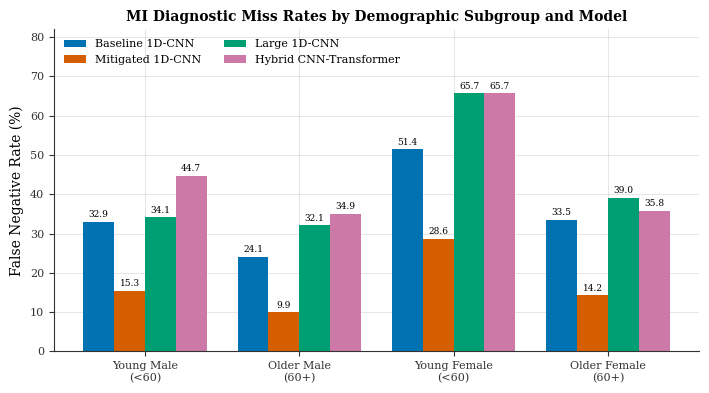

Figure 1 saved.


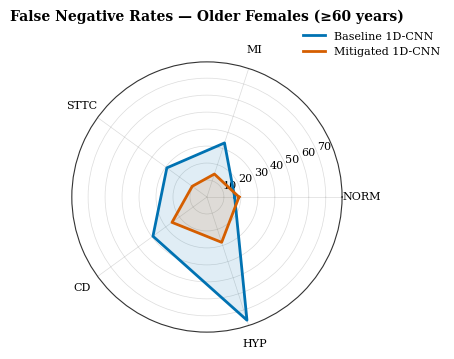

Figure 2 saved.


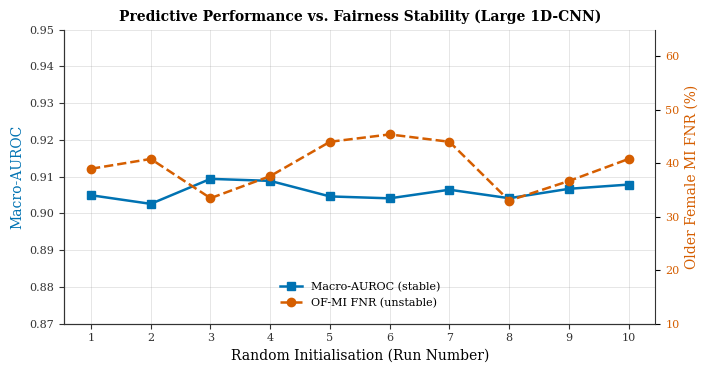

Figure 3 saved.


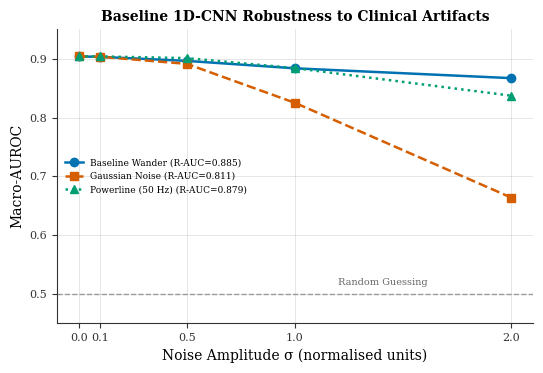

Figure 5 saved.


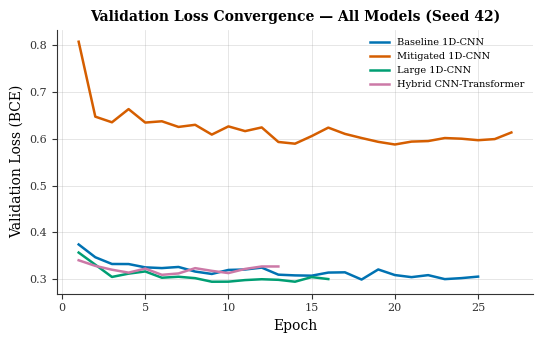

Figure 6 saved.


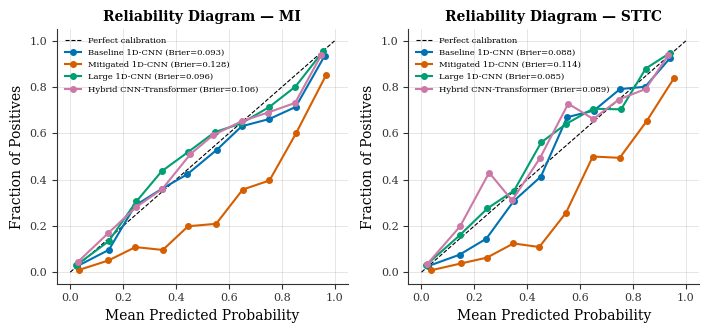

Figure 7 saved.


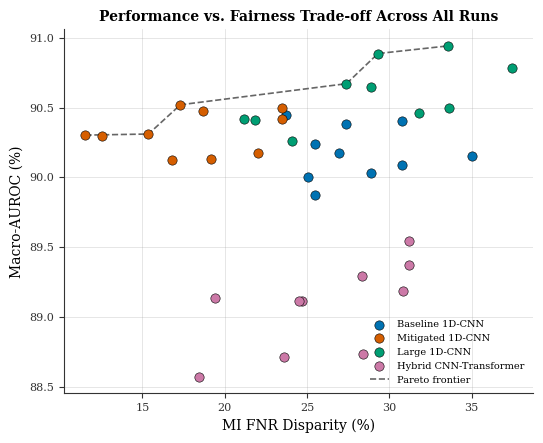

Figure 10 saved.


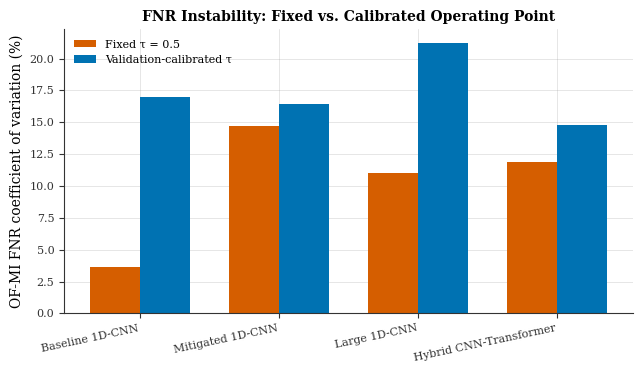

Figure 11 saved.

  Table 3: Multi-Run Classification Performance  (mean ± SD, 10 seeds)
  Model                         AUROC             F1                OF-MI FNR τ=0.5     OF-MI FNR calib.    CV-FNR(τ)
  --------------------------------------------------------------------------------------
  Baseline 1D-CNN               0.902±0.002  0.662±0.011  35.4±1.3  26.5±4.5  3.6%
  Mitigated 1D-CNN              0.903±0.001  0.685±0.005  19.6±2.9  25.2±4.2  14.7%
  Large 1D-CNN                  0.906±0.002  0.677±0.009  39.5±4.3  23.9±5.1  11.0%
  Hybrid CNN-Transformer        0.891±0.003  0.662±0.008  33.8±4.0  28.9±4.3  11.9%

All figures saved to /content/drive/MyDrive/ecg_fairness_project/figures/


In [ ]:
# %%
# ============================================================
# BLOCK 15: Paper Figures
# ============================================================

MODEL_COLORS = {
    'Baseline 1D-CNN':        '#0072B2',
    'Mitigated 1D-CNN':       '#D55E00',
    'Large 1D-CNN':           '#009E73',
    'Hybrid CNN-Transformer': '#CC79A7',
}

plt.rcParams.update({
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif'],
    'font.size':            9,
    'axes.labelsize':       10,
    'axes.titlesize':       10,
    'axes.titleweight':    'bold',
    'legend.fontsize':      8,
    'xtick.labelsize':      8,
    'ytick.labelsize':      8,
    'axes.linewidth':       0.8,
    'axes.edgecolor':      '#333333',
    'axes.grid':            True,
    'grid.linewidth':       0.5,
    'grid.alpha':           0.35,
    'grid.color':          '#999999',
    'axes.axisbelow':       True,
    'savefig.dpi':          600,
    'savefig.bbox':        'tight',
    'pdf.fonttype':         42,
    'ps.fonttype':          42,
})


def _clean_axes(ax):
    """Remove top/right spines -- standard for IEEE/Nature-style figures."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    ax.tick_params(colors='#333333')


def _save_figure(fig, name: str):
    """Save both a vector PDF, for camera-ready typesetting with
    editable text, and a raster PNG for quick preview."""
    fig.savefig(SAVE_DIR + f'{name}.pdf')
    fig.savefig(SAVE_DIR + f'{name}.png', dpi=300)


SUBGROUP_LABELS = ['Young Male\n(<60)', 'Older Male\n(60+)',
                   'Young Female\n(<60)', 'Older Female\n(60+)']


def _mi_fnr_vec(model_name):
    fnr_d = results['single_run'][model_name]['fnr']['MI']
    return [(fnr_d.get(k, (0,))[0] or 0) * 100
            if isinstance(fnr_d.get(k), tuple)
            else (fnr_d.get(k) or 0) * 100
            for k in SUBGROUPS]


def _older_female_fnr(model_name):
    fnr_d = results['single_run'][model_name]['fnr']
    return [(fnr_d[cls].get('Older Female (60+)', (0,))[0] or 0) * 100
            if isinstance(fnr_d[cls].get('Older Female (60+)'), tuple)
            else (fnr_d[cls].get('Older Female (60+)') or 0) * 100
            for cls in CLASSES]


# ---- Figure 1: MI FNR grouped bar chart ----
models_bar = list(MODEL_COLORS.keys())
x      = np.arange(4)
width  = 0.2
offset = np.linspace(-(len(models_bar)-1)/2, (len(models_bar)-1)/2,
                      len(models_bar)) * width

fig1, ax1 = plt.subplots(figsize=(7.16, 4.0))
for mn, off in zip(models_bar, offset):
    vals  = _mi_fnr_vec(mn)
    rects = ax1.bar(x + off, vals, width, label=mn, color=MODEL_COLORS[mn])
    for r in rects:
        h = r.get_height()
        ax1.annotate(f'{h:.1f}', xy=(r.get_x() + r.get_width()/2, h),
                     xytext=(0, 2), textcoords='offset points',
                     ha='center', va='bottom', fontsize=6.5)

ax1.set_ylabel('False Negative Rate (%)')
ax1.set_title('MI Diagnostic Miss Rates by Demographic Subgroup and Model')
ax1.set_xticks(x)
ax1.set_xticklabels(SUBGROUP_LABELS)
ax1.legend(loc='upper left', frameon=False, ncol=2)
ax1.set_ylim(0, 82)
_clean_axes(ax1)
plt.tight_layout()
_save_figure(fig1, 'Figure1_MI_FNR')
plt.show()
print("Figure 1 saved.")

# ---- Figure 2: Polar chart — older-female FNR, Baseline vs. Mitigated ----
radar_models = ['Baseline 1D-CNN', 'Mitigated 1D-CNN']
cats_c       = CLASSES + [CLASSES[0]]
angles       = np.linspace(0, 2 * np.pi, len(cats_c), endpoint=True)

fig2, ax2 = plt.subplots(figsize=(4.2, 4.2), subplot_kw={'projection': 'polar'})
for mn in radar_models:
    v = _older_female_fnr(mn) + [_older_female_fnr(mn)[0]]
    ax2.plot(angles, v, color=MODEL_COLORS[mn], linewidth=2, label=mn)
    ax2.fill(angles, v, color=MODEL_COLORS[mn], alpha=0.12)

ax2.set_thetagrids(np.degrees(angles[:-1]), CLASSES)
ax2.set_title('False Negative Rates — Older Females (≥60 years)', y=1.12)
ax2.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), frameon=False)
plt.tight_layout()
_save_figure(fig2, 'Figure2_Radar_OlderFemale')
plt.show()
print("Figure 2 saved.")

# ---- Figure 3: Stability — Large CNN ----
mr   = results['multi_run']['Large 1D-CNN']
runs = list(range(1, len(SEEDS) + 1))

fig3, ax_l = plt.subplots(figsize=(7.16, 3.8))
c_a, c_f = '#0072B2', '#D55E00'

ax_l.set_xlabel('Random Initialisation (Run Number)')
ax_l.set_ylabel('Macro-AUROC', color=c_a)
l1 = ax_l.plot(runs, mr['auroc'], color=c_a, marker='s', markersize=6,
               linewidth=1.8, label='Macro-AUROC (stable)')
ax_l.tick_params(axis='y', labelcolor=c_a)
ax_l.set_ylim(0.87, 0.95)
ax_l.set_xticks(runs)
_clean_axes(ax_l)

ax_r = ax_l.twinx()
ax_r.set_ylabel('Older Female MI FNR (%)', color=c_f)
l2 = ax_r.plot(runs, mr['fnr_fixed'], color=c_f, marker='o', markersize=6,
               linewidth=1.8, linestyle='--', label='OF-MI FNR (unstable)')
ax_r.tick_params(axis='y', labelcolor=c_f)
ax_r.set_ylim(10, 65)
ax_r.grid(False)
ax_r.spines['top'].set_visible(False)

all_lines = l1 + l2
ax_l.legend(all_lines, [l.get_label() for l in all_lines],
            loc='lower center', bbox_to_anchor=(0.5, 0.02), frameon=False)
ax_l.set_title('Predictive Performance vs. Fairness Stability (Large 1D-CNN)')
plt.tight_layout()
_save_figure(fig3, 'Figure3_Stability')
plt.show()
print("Figure 3 saved.")

# ---- Figure 5: Robustness — three noise types ----
NOISE_STYLES = {
    'baseline_wander': ('#0072B2', '-',  'o', 'Baseline Wander'),
    'gaussian':        ('#D55E00', '--', 's', 'Gaussian Noise'),
    'powerline_50hz':  ('#009E73', ':',  '^', 'Powerline (50 Hz)'),
}
noise_levels_plot = [0.0, 0.1, 0.5, 1.0, 2.0]

fig5, ax5 = plt.subplots(figsize=(5.5, 3.8))
for nt, (color, ls, marker, label) in NOISE_STYLES.items():
    aurs = [robustness_results[nt][s] for s in noise_levels_plot]
    rauc = robustness_results[nt]['robustness_auc']
    ax5.plot(noise_levels_plot, aurs, color=color, linestyle=ls, marker=marker,
             markersize=6, linewidth=1.8, label=f"{label} (R-AUC={rauc:.3f})")

ax5.axhline(0.5, color='#999999', linestyle='--', linewidth=1.0)
ax5.text(1.2, 0.515, 'Random Guessing', color='#666666', fontsize=7)
ax5.set_xlabel('Noise Amplitude σ (normalised units)')
ax5.set_ylabel('Macro-AUROC')
ax5.set_title('Baseline 1D-CNN Robustness to Clinical Artifacts')
ax5.set_xticks(noise_levels_plot)
ax5.set_ylim(0.45, 0.95)
ax5.legend(frameon=False, fontsize=6.5)
_clean_axes(ax5)
plt.tight_layout()
_save_figure(fig5, 'Figure5_Robustness')
plt.show()
print("Figure 5 saved.")

# ---- Figure 6: Validation loss convergence ----
conv_data = {mname: hist for mname, hist in _histories.items() if hist is not None}

if not conv_data:
    print("No training history available for any model — skipping Figure 6. "
          "Delete the affected seed-42 checkpoints and rerun Block 11 to "
          "regenerate history, then rerun this cell.")
else:
    fig6, ax6 = plt.subplots(figsize=(5.5, 3.5))
    for mname, hist in conv_data.items():
        ep = list(range(1, hist['n_epochs'] + 1))
        ax6.plot(ep, hist['val_loss'], label=mname, color=MODEL_COLORS[mname], linewidth=1.8)
    ax6.set_xlabel('Epoch')
    ax6.set_ylabel('Validation Loss (BCE)')
    ax6.set_title('Validation Loss Convergence — All Models (Seed 42)')
    ax6.legend(frameon=False, fontsize=7)
    _clean_axes(ax6)
    plt.tight_layout()
    _save_figure(fig6, 'Figure6_Convergence')
    plt.show()
    print("Figure 6 saved.")
    if len(conv_data) < len(MODEL_COLORS):
        missing = set(MODEL_COLORS) - set(conv_data)
        print(f"Note: missing history for {missing} — regenerate before finalizing.")

# ---- Figure 7: Reliability diagrams for MI and STTC ----
fig7, axes7 = plt.subplots(1, 2, figsize=(7.16, 3.4))

for ax, cls in zip(axes7, ['MI', 'STTC']):
    cls_idx = CLASSES.index(cls)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Perfect calibration')

    for mname, mdata in results['single_run'].items():
        tgt   = mdata['pred_dict']['targets'][:, cls_idx]
        probs = mdata['pred_dict']['probs'][:, cls_idx]
        if tgt.sum() < 20:
            continue
        prob_true, prob_pred = calibration_curve(tgt, probs, n_bins=10, strategy='uniform')
        brier = mdata['brier'][cls]
        ax.plot(prob_pred, prob_true, marker='o', markersize=4, linewidth=1.5,
                color=MODEL_COLORS.get(mname, 'grey'), label=f"{mname} (Brier={brier:.3f})")

    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'Reliability Diagram — {cls}')
    ax.legend(loc='upper left', fontsize=6, frameon=False)
    _clean_axes(ax)

plt.tight_layout()
_save_figure(fig7, 'Figure7_Reliability')
plt.show()
print("Figure 7 saved.")

# ---- Figure 10: Pareto frontier — AUROC vs. MI FNR disparity ----
def pareto_frontier(points: list) -> list:
    pts = sorted(points, key=lambda p: p[0])
    frontier, best_auroc = [], -1
    for disp, auroc in pts:
        if auroc > best_auroc:
            frontier.append((disp, auroc))
            best_auroc = auroc
    return frontier


fig10, ax10 = plt.subplots(figsize=(5.5, 4.5))
all_points = []
for mname in MODEL_COLORS:
    mr_ = results['multi_run'][mname]
    disp_vals  = mr_['fnr_disparity']['MI']
    auroc_vals = mr_['auroc']
    ax10.scatter(disp_vals, [a * 100 for a in auroc_vals][:len(disp_vals)],
                 color=MODEL_COLORS[mname], label=mname, s=45,
                 edgecolor='black', linewidth=0.4, zorder=3)
    all_points.extend(zip(disp_vals, [a * 100 for a in auroc_vals][:len(disp_vals)]))

frontier = pareto_frontier(all_points)
fx, fy = zip(*sorted(frontier))
ax10.plot(fx, fy, color='#666666', linestyle='--', linewidth=1.2, zorder=2, label='Pareto frontier')

ax10.set_xlabel('MI FNR Disparity (%)')
ax10.set_ylabel('Macro-AUROC (%)')
ax10.set_title('Performance vs. Fairness Trade-off Across All Runs')
ax10.legend(frameon=False, fontsize=7)
_clean_axes(ax10)
plt.tight_layout()
_save_figure(fig10, 'Figure10_Pareto_Frontier')
plt.show()
print("Figure 10 saved.")

# ---- Figure 11: Fixed vs. calibrated-threshold FNR CV ----
fig11, ax11 = plt.subplots(figsize=(6.5, 3.8))
model_names = list(MODEL_COLORS.keys())
cv_fixed    = [results['multi_run'][m]['summary']['fnr_fixed'][3] for m in model_names]
cv_calib    = [results['multi_run'][m]['summary']['fnr_calibrated'][3] for m in model_names]

xb = np.arange(len(model_names))
ax11.bar(xb - 0.18, cv_fixed, 0.36, label='Fixed τ = 0.5',           color='#D55E00')
ax11.bar(xb + 0.18, cv_calib, 0.36, label='Validation-calibrated τ', color='#0072B2')
ax11.set_xticks(xb)
ax11.set_xticklabels(model_names, rotation=12, ha='right')
ax11.set_ylabel('OF-MI FNR coefficient of variation (%)')
ax11.set_title('FNR Instability: Fixed vs. Calibrated Operating Point')
ax11.legend(frameon=False)
_clean_axes(ax11)
plt.tight_layout()
_save_figure(fig11, 'Figure11_Threshold_Sensitivity')
plt.show()
print("Figure 11 saved.")

print_results_table()
print(f"All figures saved to {SAVE_DIR}")

In [ ]:
# %%
# ============================================================
# BLOCK 16: External Validation Dataset
#           Georgia 12-Lead ECG Challenge Database
#
# The Georgia database (Perez Alday et al., 2020; PhysioNet/CinC
# Challenge 2020) contains 10,344 twelve-lead recordings from the
# Southeastern United States, collected independently of PTB-XL.
# Recordings are provided in WFDB format at 500 Hz with age, sex,
# and SNOMED-CT diagnosis codes in each header file. Only the
# Georgia source is downloaded, not the full Challenge archive.
# ============================================================

EXTERNAL_DIR = '/content/georgia'

if os.path.exists(EXTERNAL_DIR) and len(os.listdir(EXTERNAL_DIR)) > 0:
    print(f"Georgia database already present at: {EXTERNAL_DIR}")
else:
    print("Downloading the Georgia 12-lead ECG database from PhysioNet...")
    subprocess.run(
        ["wget", "-r", "-N", "-c", "-np", "-nH", "--cut-dirs=4",
         "-R", "index.html*", "-P", "/content",
         "https://physionet.org/files/challenge-2020/1.0.2/training/georgia/"],
        check=True
    )
    assert os.path.exists(EXTERNAL_DIR), f"Download failed. Expected: {EXTERNAL_DIR}"
    print(f"Georgia database ready: {EXTERNAL_DIR}")

_georgia_headers = sorted(glob.glob(f"{EXTERNAL_DIR}/**/*.hea", recursive=True))
print(f"Georgia recordings found: {len(_georgia_headers):,}")

In [ ]:
# %%
# ============================================================
# BLOCK 17: SNOMED-CT to Diagnostic Superclass Mapping
#
#   NORM  — normal sinus rhythm and its benign variants
#   MI    — myocardial infarction, any territory or stage
#   STTC  — ischaemic ST/T-wave change without infarction
#   CD    — atrioventricular, bundle-branch, or fascicular block
#   HYP   — atrial or ventricular hypertrophy
#
# Diagnoses outside these five categories fall outside PTB-XL's own
# diagnostic taxonomy and are not scored. Recordings whose only
# diagnoses fall in that remainder are excluded in Block 18. The
# full crosswalk is printed below for manual review.
# ============================================================

DX_MAP_URL = ("https://raw.githubusercontent.com/physionetchallenges/"
              "physionetchallenges.github.io/master/2020/Dx_map.csv")
dx_map_df  = pd.read_csv(DX_MAP_URL)
dx_map_df.columns = ['description', 'snomed_code', 'abbreviation']

_SUPERCLASS_KEYWORDS = {
    'NORM': ['sinus rhythm', 'sinus arrhythmia'],
    'MI':   ['myocardial infarction'],
    'STTC': ['ischemia', 'ischaemia', 'st segment', 't wave abnormal',
             'st-t', 'nonspecific st'],
    'CD':   ['av block', 'atrioventricular block', 'bundle branch block',
             'fascicular block', 'intraventricular conduction',
             'wolff-parkinson-white'],
    'HYP':  ['hypertrophy'],
}


def map_description_to_superclass(description):
    """Assign a SNOMED-CT description to a superclass, or None if
    outside the taxonomy. MI is checked before STTC so infarction-
    specific phrasing is never re-classified as ischaemia."""
    text = description.lower()
    for superclass, keywords in _SUPERCLASS_KEYWORDS.items():
        if any(kw in text for kw in keywords):
            return superclass
    return None

dx_map_df['superclass'] = dx_map_df['description'].apply(map_description_to_superclass)

dx_map_df['snomed_code'] = (
    dx_map_df['snomed_code']
    .astype(str)
    .str.replace(r'\.0$', '', regex=True)
    .str.strip()
)

SNOMED_TO_SUPERCLASS = dict(zip(dx_map_df['snomed_code'], dx_map_df['superclass']))

print("SNOMED-CT -> Diagnostic Superclass crosswalk:")
print(dx_map_df[dx_map_df['superclass'].notna()]
      [['description', 'snomed_code', 'superclass']]
      .sort_values('superclass').to_string(index=False))
print(f"\n{dx_map_df['superclass'].notna().sum()} of {len(dx_map_df)} SNOMED-CT "
      f"codes map onto the five-superclass taxonomy.")

In [ ]:
# %%
# ============================================================
# BLOCK 18: External Preprocessing, Dataset & DataLoader
#
# Signals are resampled from their native 500 Hz to 100 Hz and
# truncated or zero-padded to 1000 samples, then per-lead z-score
# normalised identically to PTBXLDataset — no architectural or
# preprocessing changes are made across the domain shift.
# ============================================================

PTBXL_FS, PTBXL_LEN = 100, 1000


def parse_georgia_header(path: str) -> dict:
    """Extract age, sex, and Dx SNOMED codes from a WFDB header.
    Tolerant of an optional space after '#' and of field-name case,
    since these vary across PhysioNet Challenge sources."""
    age, sex, dx_codes = np.nan, np.nan, []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line.startswith('#'):
                continue
            content = line.lstrip('#').strip()
            field, _, value = content.partition(':')
            field = field.strip().lower()
            value = value.strip()

            if field == 'age':
                age = float(value) if value.replace('.', '', 1).isdigit() else np.nan
            elif field == 'sex':
                value_l = value.lower()
                if value_l.startswith('f'):
                    sex = 1
                elif value_l.startswith('m'):
                    sex = 0
            elif field == 'dx':
                dx_codes = [c.strip() for c in value.split(',') if c.strip()]

    return {'age': age, 'sex': sex, 'dx_codes': dx_codes}


def build_georgia_dataframe(header_paths: list) -> pd.DataFrame:
    """Parse all headers and multi-hot encode the five superclasses."""
    records = []
    for path in header_paths:
        meta   = parse_georgia_header(path)
        labels = {c: 0 for c in CLASSES}
        for code in meta['dx_codes']:
            superclass = SNOMED_TO_SUPERCLASS.get(code)
            if superclass is not None:
                labels[superclass] = 1
        if sum(labels.values()) == 0:
            continue
        records.append({
            'record_path': path[:-len('.hea')],
            'age': meta['age'],
            'sex': meta['sex'],
            **{f'label_{c}': labels[c] for c in CLASSES},
        })
    return pd.DataFrame(records)

georgia_df = build_georgia_dataframe(_georgia_headers)

if len(georgia_df) == 0:
    sample_codes = []
    for path in _georgia_headers[:20]:
        sample_codes.extend(parse_georgia_header(path)['dx_codes'])
    print("No Georgia records matched the five-superclass taxonomy.")
    print(f"Sample codes seen in headers: {sorted(set(sample_codes))[:15]}")
    print(f"Sample codes in crosswalk:    {sorted(SNOMED_TO_SUPERCLASS.keys())[:15]}")
    raise RuntimeError(
        "georgia_df is empty — compare the two code lists printed above; "
        "a formatting mismatch (e.g. trailing '.0') means the join is failing silently."
    )

georgia_df = georgia_df.dropna(subset=['sex']).reset_index(drop=True)
georgia_df['age'] = georgia_df['age'].fillna(georgia_df['age'].median())

def _has_finite_signal(record_path: str) -> bool:
    """
    True if a record's raw signal contains no NaN/Inf samples. A
    minority of Georgia recordings encode missing samples using a
    WFDB sentinel value that wfdb.rdsamp converts to NaN; scipy's
    FFT-based resample then spreads that single NaN across every
    sample in the resampled channel, corrupting model input.
    """
    try:
        signal, _ = wfdb.rdsamp(record_path)
    except Exception:
        return False
    return np.isfinite(signal).all()


_n_before   = len(georgia_df)
finite_mask = georgia_df['record_path'].apply(_has_finite_signal)
georgia_df  = georgia_df[finite_mask].reset_index(drop=True)
print(f"Excluded {_n_before - len(georgia_df)} of {_n_before} recordings "
      f"with non-finite (NaN/Inf) raw signal values.")

print(f"Georgia external test set: {len(georgia_df):,} recordings")
print("\nClass prevalence:")
for c in CLASSES:
    print(f"  {c}: {int(georgia_df[f'label_{c}'].sum()):,}")
print(f"\nFemale: {(georgia_df['sex'] == 1).mean():.1%}  |  "
      f"Age >= 60: {(georgia_df['age'] >= 60).mean():.1%}")


class GeorgiaECGDataset(Dataset):
    """Streaming loader for the Georgia database, resampled to the
    100 Hz / 1000-sample format the PTB-XL-trained models expect."""
    def __init__(self, df: pd.DataFrame, class_names: list):
        self.df     = df
        self.labels = df[[f'label_{c}' for c in class_names]].values.astype(np.float32)
        self.sex    = df['sex'].values.astype(np.float32)
        self.age    = df['age'].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        signal, meta = wfdb.rdsamp(self.df.iloc[idx]['record_path'])
        signal = np.nan_to_num(signal, nan=0.0, posinf=0.0, neginf=0.0)
        native_fs = meta['fs']
        n_target     = int(round(signal.shape[0] * PTBXL_FS / native_fs))
        signal       = sp_resample(signal, n_target, axis=0)

        if len(signal) >= PTBXL_LEN:
            signal = signal[:PTBXL_LEN]
        else:
            signal = np.pad(signal, ((0, PTBXL_LEN - len(signal)), (0, 0)))

        signal = signal.T
        mu     = signal.mean(axis=1, keepdims=True)
        sigma  = signal.std(axis=1, keepdims=True)
        signal = (signal - mu) / (sigma + 1e-8)

        return (
            torch.tensor(signal, dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32),
            {'sex': self.sex[idx], 'age': self.age[idx], 'ecg_id': idx},
        )


georgia_dataset = GeorgiaECGDataset(georgia_df, CLASSES)
georgia_loader  = DataLoader(georgia_dataset, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=0, pin_memory=False)

for x, y, _ in georgia_loader:
    print(f"\nGeorgia batch shape — Signal: {x.shape}  Labels: {y.shape}")
    break

In [ ]:
# %%
# ============================================================
# BLOCK 19: Zero-Shot External Inference — Overall Performance
#
# Every model already trained on PTB-XL is evaluated on Georgia
# with no retraining, no fine-tuning, and no access to Georgia
# demographic labels during inference.
# ============================================================

results['external'] = {'single_run': {}, 'multi_run': {}}

_external_specs = [
    ('Baseline 1D-CNN',        ECG_1D_CNN),
    ('Mitigated 1D-CNN',       ECG_1D_CNN),
    ('Large 1D-CNN',           ECG_Large_CNN),
    ('Hybrid CNN-Transformer', Hybrid_ECG_Transformer),
]

print(f"{'Model':<32}  {'AUROC [95% CI]':<26}  {'F1 [95% CI]':<26}  Brier")
print("-" * 92)

for mname, mclass in _external_specs:
    model    = load_checkpoint(mclass(num_classes=5), mname, PRIMARY_SEED)
    pd_      = get_predictions(model, georgia_loader)
    metrics  = compute_overall_metrics(pd_)
    brier    = compute_brier_scores(pd_)
    auroc_ci = bootstrap_metric_ci(pd_, metric='auroc')
    f1_ci    = bootstrap_metric_ci(pd_, metric='f1')

    results['external']['single_run'][mname] = {
        'auroc': metrics['auroc'], 'f1': metrics['f1'],
        'auroc_ci': auroc_ci, 'f1_ci': f1_ci, 'brier': brier, 'pred_dict': pd_,
    }
    print(f"{mname:<32}  "
          f"{metrics['auroc']:.4f} [{auroc_ci[0]:.4f},{auroc_ci[1]:.4f}]  "
          f"{metrics['f1']:.4f} [{f1_ci[0]:.4f},{f1_ci[1]:.4f}]  "
          f"{brier['macro']:.4f}")

In [ ]:
# %%
# ============================================================
# BLOCK 20: External Fairness Audit
#
# The same FNR-parity, equalized-odds, and subgroup-count
# machinery used for PTB-XL is applied unmodified to the Georgia
# predictions.
# ============================================================

for mname, mdata in results['external']['single_run'].items():
    fnr       = compute_fnr_by_group(mdata['pred_dict'], with_ci=True)
    fpr       = compute_fpr_by_group(mdata['pred_dict'], with_ci=True)
    disparity = compute_fnr_disparity(fnr)
    eo_gap    = compute_equalized_odds_gap(fnr, fpr)
    counts    = compute_subgroup_counts(mdata['pred_dict'])

    mdata['fnr']       = fnr
    mdata['fpr']       = fpr
    mdata['disparity'] = disparity
    mdata['eo_gap']    = eo_gap
    mdata['counts']    = counts

    print_fairness_report(f"{mname} — Georgia (External)", fnr, disparity, counts)
    print_equalized_odds_report(f"{mname} — Georgia (External)", fnr, fpr)

In [ ]:
# %%
# ============================================================
# BLOCK 21: Cross-Domain Stability Analysis
#
# Block 12 already trained each architecture across ten
# independent seeds. Reusing those checkpoints here, with no
# additional training, tests whether the AUROC-stable / FNR-
# unstable discordance replicates under domain shift.
#
# STTC is tracked as the headline cross-domain fairness metric
# rather than MI: Georgia's MI prevalence under SNOMED-CT mapping
# (n=7 total, n=0-3 per subgroup) is too sparse to distinguish
# genuine instability from single-case sampling noise. STTC
# (n=1195 in the Older Female subgroup) supports a meaningful
# estimate. MI is still tracked and reported separately, flagged
# as underpowered.
# ============================================================

def run_external_stability(model_class, model_name: str,
                            seeds: list = SEEDS,
                            tracked_class: str = 'STTC',
                            tracked_group: str = 'Older Female (60+)') -> dict:
    """Load each existing seed checkpoint and evaluate on Georgia."""
    run_auroc, run_fnr_tracked, run_fnr_mi = [], [], []
    run_disparity = {cls: [] for cls in CLASSES}

    for seed in seeds:
        model    = load_checkpoint(model_class(num_classes=5), model_name, seed)
        pd_      = get_predictions(model, georgia_loader)
        met      = compute_overall_metrics(pd_)
        fnr_dict = compute_fnr_by_group(pd_)
        disp     = compute_fnr_disparity(fnr_dict)

        tracked_val = fnr_dict[tracked_class].get(tracked_group)
        mi_val      = fnr_dict['MI'].get(tracked_group)

        run_auroc.append(met['auroc'])
        if tracked_val is not None:
            run_fnr_tracked.append(tracked_val * 100)
        if mi_val is not None:
            run_fnr_mi.append(mi_val * 100)
        for cls in CLASSES:
            if disp.get(cls) is not None:
                run_disparity[cls].append(disp[cls] * 100)

    am, as_, aci = calc_stats(run_auroc)
    tm, ts_, tci = calc_stats(run_fnr_tracked)
    auroc_cv     = as_ / am * 100
    tracked_cv   = ts_ / tm * 100 if tm > 0 else 0

    print(f"\n{model_name}  (Georgia, {len(seeds)} seeds)")
    print(f"  AUROC                        : {am:.4f} ± {as_:.4f}  CV = {auroc_cv:.2f}%")
    print(f"  OF-{tracked_class} FNR (well-powered) : {tm:.2f}% ± {ts_:.2f}%  CV = {tracked_cv:.2f}%")
    if run_fnr_mi:
        mm, ms_, _ = calc_stats(run_fnr_mi)
        mi_cv = ms_ / mm * 100 if mm > 0 else float('nan')
        print(f"  OF-MI FNR (n=3, underpowered) : {mm:.2f}% ± {ms_:.2f}%  "
              f"CV = {mi_cv:.2f}%  [not used for cross-domain comparison]")

    return {
        'auroc': run_auroc,
        'fnr_tracked': run_fnr_tracked, 'tracked_class': tracked_class,
        'fnr_mi_underpowered': run_fnr_mi,
        'fnr_disparity': run_disparity,
        'summary': {
            'auroc':   (am, as_, aci, auroc_cv),
            'tracked': (tm, ts_, tci, tracked_cv),
        },
    }


for mname, mclass in _external_specs:
    results['external']['multi_run'][mname] = run_external_stability(mclass, mname)

print(f"\n{'='*95}")
print(f"  Table: Cross-Domain Stability — PTB-XL (Internal, MI) vs. Georgia (External, STTC)")
print(f"{'='*95}")
print(f"  {'Model':<28}  {'PTB-XL AUROC CV':<16}  {'Georgia AUROC CV':<17}  "
      f"{'PTB-XL MI-FNR CV':<17}  {'Georgia STTC-FNR CV'}")
print(f"  {'-'*95}")
for mname, mclass in _external_specs:
    ptbxl_cv    = results['multi_run'][mname]['summary']['auroc'][3]
    georgia_cv  = results['external']['multi_run'][mname]['summary']['auroc'][3]
    ptbxl_fcv   = results['multi_run'][mname]['summary']['fnr_fixed'][3]
    georgia_fcv = results['external']['multi_run'][mname]['summary']['tracked'][3]
    print(f"  {mname:<28}  {ptbxl_cv:>13.2f}%  {georgia_cv:>14.2f}%  "
          f"{ptbxl_fcv:>14.1f}%  {georgia_fcv:>17.1f}%")

In [ ]:
# %%
# ============================================================
# BLOCK 22: External Validation Figures
#
# STTC is used as the headline subgroup fairness metric for
# Georgia rather than MI: Georgia's MI prevalence under SNOMED-CT
# mapping (n=7 total) is too sparse to support a meaningful
# subgroup-level FNR estimate, whereas STTC (n=4,171) gives well-
# powered comparisons across all four intersectional subgroups.
# ============================================================

EXTERNAL_TRACKED_CLASS = 'STTC'

fig8, ax8   = plt.subplots(figsize=(7.16, 4.0))
group_names = list(SUBGROUPS.keys())
x           = np.arange(len(group_names))
width       = 0.2

for i, (mname, _) in enumerate(_external_specs):
    fnr_dict = results['external']['single_run'][mname]['fnr']
    counts   = results['external']['single_run'][mname]['counts']
    vals, ns = [], []
    for g in group_names:
        v = fnr_dict[EXTERNAL_TRACKED_CLASS][g]
        v = v[0] if isinstance(v, tuple) else v
        vals.append((v or 0) * 100)
        ns.append(counts[EXTERNAL_TRACKED_CLASS][g])
    rects = ax8.bar(x + (i - 1.5) * width, vals, width,
                    label=mname, color=MODEL_COLORS[mname])

ax8.set_xticks(x)
ax8.set_xticklabels(group_names, rotation=12, ha='right')
ax8.set_ylabel('False Negative Rate (%)')
ax8.set_title(f'{EXTERNAL_TRACKED_CLASS} Diagnostic Miss Rates by Demographic Subgroup and Model\n'
              '(External Validation — Georgia 12-Lead ECG Database)', pad=45)
ax8.legend(loc='upper center', bbox_to_anchor=(0.5, 1.14), ncol=4,
           frameon=False, fontsize=7.5, columnspacing=1.2)
_clean_axes(ax8)
plt.tight_layout()
_save_figure(fig8, 'Figure8_External_STTC_FNR')
plt.show()
print("Figure 8 saved.")

print(f"\nSubgroup positive counts for {EXTERNAL_TRACKED_CLASS} (Georgia), for reference:")
ref_counts = results['external']['single_run']['Baseline 1D-CNN']['counts'][EXTERNAL_TRACKED_CLASS]
for g, n in ref_counts.items():
    print(f"  {g}: n={n}")

# ---- Figure 9: Cross-domain FNR-CV comparison ----
# PTB-XL's bars report Older Female MI FNR CV (its own well-powered
# headline class); Georgia's bars report Older Female STTC FNR CV,
# the best-powered comparable class in this external cohort. The
# two are not the same disease category -- the legend states this
# explicitly rather than implying a like-for-like MI comparison.
fig9, ax9   = plt.subplots(figsize=(7.16, 4.2))
model_names = [m for m, _ in _external_specs]
ptbxl_cvs   = [results['multi_run'][m]['summary']['fnr_fixed'][3] for m in model_names]
georgia_cvs = [results['external']['multi_run'][m]['summary']['tracked'][3] for m in model_names]

xg = np.arange(len(model_names))
ax9.bar(xg - 0.2, ptbxl_cvs,   0.4, label='PTB-XL — Older Female MI FNR',
        color='#0072B2')
ax9.bar(xg + 0.2, georgia_cvs, 0.4, label=f'Georgia — Older Female {EXTERNAL_TRACKED_CLASS} FNR',
        color='#D55E00')
ax9.set_xticks(xg)
ax9.set_xticklabels(model_names, rotation=12, ha='right')
ax9.set_ylabel('FNR coefficient of variation (%)')
ax9.set_title('FNR Instability Across Seeds: PTB-XL (MI) vs. External Validation (STTC)')
ax9.legend(frameon=False)
_clean_axes(ax9)
plt.tight_layout()
_save_figure(fig9, 'Figure9_CrossDomain_Stability')
plt.show()
print("Figure 9 saved.")

print(f"\nNote: Georgia MI prevalence (n=7 total) was too sparse for reliable "
      f"subgroup-level FNR reporting; {EXTERNAL_TRACKED_CLASS} is reported here "
      f"as the best-powered comparable class. Georgia's own MI results are "
      f"available in results['external']['multi_run'][model]['fnr_mi_underpowered'] "
      f"and reported separately with an explicit low-power caveat.")